<a href="https://colab.research.google.com/github/mtate/AI/blob/main/Wind_Turbine_Failure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Aeolus Renewables is an independent power producer operating a fleet of 1,150 onshore wind turbines (2.5 MW class) across 16 wind farms in the central plains region, with a combined installed capacity of roughly 2.87 GW. The company sells the electricity its turbines produce to the grid under long-term power purchase agreements, where revenue is tied directly to how much energy is delivered - so every hour a turbine is offline is energy that cannot be sold. A regional operations centre monitors the fleet around the clock, supported by an O&M organisation of about 140 field technicians.

Each turbine continuously streams condition data through its SCADA (Supervisory Control and Data Acquisition) system - drivetrain vibration, bearing and oil temperatures, rotor and generator speed, and power output - recorded as 10-minute averages, the standard logging resolution for utility-scale turbines. The exact channels vary by turbine type, but together they describe the health of the main subassemblies in near-real time. Today, maintenance runs on a mix of fixed-interval inspections and reactive repair: technicians follow a scheduled service calendar, and the control room responds when an automated alarm trips or a turbine faults offline.

The most consequential components are in the drivetrain - the gearbox and main bearing - which are expensive, slow to procure, and require a mobile crane to replace. The gearbox alone represents approximately 13% of the overall capital cost of an onshore turbine, and within gearboxes the failures are dominated by bearings: one widely-cited breakdown puts the split at bearings (70%), gears (26%) and other causes (4%). The core problem is recognition. By the time a drivetrain fault has developed far enough to matter, its signature is real but still tangled in normal operating noise across many channels - and the existing fixed thresholds only trip once the fault is near-catastrophic, when the turbine is already offline or the component has seized. A genuinely fault drivetrain can run for hours or days looking "normal" to a threshold alarm, while a control-room analyst has no practical way to tell it apart from a healthy machine reacting to gusty wind. The consequences:

- Each unplanned drivetrain failure takes a turbine offline for an estimated 7–21 days, directly forfeiting saleable energy under the power purchase agreement.
- Emergency crane mobilisation and expedited parts run at a steep premium over the same work scheduled in advance, making an unplanned gearbox replacement a major cost event.
- A degrading main bearing left running frequently destroys the gearbox it feeds, converting a contained repair into a far larger one.
- Control-room analysts manually scan a flood of channels across 1,150 turbines, and alarm fatigue means genuine degradation signals slip through unnoticed until the machine faults offline.


## **Objective**

This proof of concept builds a drivetrain-condition classifier that reads each turbine's live sensor signature and labels the drivetrain as "fault" or "normal", serving operations-centre analysts and maintenance planners. The solution

- Reads each turbine's multi-channel sensor signature and produces a clear fault-vs-normal signal, so analysts can concentrate on the handful of machines genuinely in a fault condition rather than scanning the whole fleet.
- Distinguishes a truly fault drivetrain from normal operating noise more reliably than fixed thresholds, catching faults that are present but not yet severe enough to trip a catastrophic alarm - the window in which a turbine can still be stopped before a bearing fault cascades into gearbox destruction.
Is deliberately tuned to favour catching true failures over avoiding false alerts, because a missed fault drivetrain costs far more than an unnecessary inspection.
- Establishes a measurable detection baseline on historical fleet data, so the capability's accuracy and its operational value can be judged on evidence before any wider rollout.

Once proven at proof-of-concept scale, this capability would give Aeolus a defensible basis to move drivetrain maintenance from reactive repair toward condition-based intervention - reducing unplanned downtime, protecting saleable energy revenue, and containing repairs before they escalate across a 1150-turbine fleet.

## **Data Dictionary**

The dataset, `wind_turbine_detection.csv` contains 10-minute SCADA records for 15 turbines.

### Identifiers & Metadata

| Column | Data Type | Description |
| --- | --- | --- |
| timestamp | datetime | Date and time of the 10-minute logging interval; establishes chronological sequence. |
| turbine_id | object (categorical) | Unique code identifying individual wind turbines; used to track specific asset history. |

### Environmental Conditions

| Column | Data Type | Description |
| --- | --- | --- |
| rated_power_kW | float | Maximum engineered power capacity of the turbine; defines its performance baseline. |
| wind_speed_mps | float | Velocity of the incoming wind; the primary driver of kinetic energy input. |
| wind_direction_deg | float | Compass direction of oncoming wind; used to assess turbine alignment. |
| turbulence_intensity | float | Measure of wind speed fluctuation; higher intensity increases structural fatigue. |
| air_density_kgm3 | float | Mass of air per unit volume; directly impacts aerodynamic lift and power potential. |
| ambient_temp_C | float | Outdoor air temperature surrounding the turbine; affects cooling efficiency. |
| humidity_pct | float | Relative moisture level in the air; flags risks for electrical insulation degradation or corrosion. |

### Operational Control & State

| Column | Data Type | Description |
| --- | --- | --- |
| power_output_kW | float | Real-time electricity generated; drops or fluctuations can signal mechanical drag. |
| rotor_speed_rpm | float | Rotational speed of the main blades; reflects low-speed shaft dynamics. |
| generator_speed_rpm | float | Rotational speed of the generator shaft; crucial for detecting gearbox slip. |
| blade_pitch_angle_deg | float | Angle of the blades relative to the wind; adjusted to control power and rotor speed. |
| yaw_misalignment_deg | float | Angle deviation between wind direction and nacelle orientation; high values cause uneven drivetrain stress. |

### Thermal Metrics (Component Health)

| Column | Data Type | Description |
| --- | --- | --- |
| gearbox_oil_temp_C | float | Temperature of the lubricating oil; spikes indicate excessive mechanical friction. |
| gearbox_bearing_temp_C | float | Internal temperature of gearbox bearings; a leading indicator of bearing wear. |
| generator_bearing_temp_C | float | Temperature of generator bearings; flags alignment or lubrication issues. |
| generator_winding_temp_C | float | Temperature of internal electrical coils; spikes indicate electrical overload or cooling failure. |
| main_bearing_temp_C | float | Temperature of the primary low-speed shaft bearing; handles massive structural loads. |
| nacelle_temp_C | float | Air temperature inside the enclosed housing; reflects global internal heat dissipation. |

### Vibration & Diagnostics (FFT)

| Column | Data Type | Description |
| --- | --- | --- |
| drivetrain_vibration_rms_mmps | float | Overall energy of drivetrain vibrations; general indicator of mechanical roughness. |
| tower_vibration_mmps | float | Structural oscillation of the turbine tower; flags aerodynamic or rotor imbalance. |
| vib_fft_bearing_bpfo | float | Vibration amplitude at the bearing outer-race defect frequency; tracks outer-ring pitting. |
| vib_fft_bearing_bpfi | float | Vibration amplitude at the bearing inner-race defect frequency; tracks inner-ring pitting. |
| vib_fft_gearmesh | float | Vibration amplitude at the teeth-meshing frequency; isolates gearbox tooth wear or misalignment. |
| vib_fft_sideband | float | Vibration amplitude surrounding main frequencies; flags localized faults like cracked gear teeth. |

### Lubrication & Particle Analysis

| Column | Data Type | Description |
| --- | --- | --- |
| oil_particle_count | float | Quantity of metallic debris suspended in lubricating oil; direct indicator of component wear. |
| oil_pressure_bar | float | Pressure of the lubrication system; drops indicate leaks, pump failures, or oil thinning. |

### Asset Lifecycle & History

| Column | Data Type | Description |
| --- | --- | --- |
| operating_hours_total | float | Cumulative runtime of the turbine; represents the asset's total mechanical mileage. |
| cumulative_energy_MWh | float | Total historical electricity produced; measures the lifetime work done by the drivetrain. |
| load_cycles | int | Total count of fatigue-inducing stress variations; correlates directly with structural aging. |
| hours_since_last_maintenance | float | Time elapsed since last service; crucial for identifying maintenance-cycle fatigue. |
| prior_fault_count | int | Total historical fault events triggered; highlights chronic or poorly repaired issues. |
| component_age_days | float | Elapsed lifetime of active components; captures chronological wear independent of runtime. |

### Targets (Labels)

| Column | Data Type | Description |
| --- | --- | --- |
| failure | int (0/1) | The target variable; boolean flag indicating if the drivetrain or turbine is healthy (0) or failing (1). |

# **Please read the instructions carefully before starting the project.**

This is a template Python notebook file in which high-level instructions and tasks to be performed are mentioned, along with pre-filled code blocks in certain sections.

* Feel free to conduct the analysis and build and evaluate the predictive models using AI to generate the necessary code or writing the necessary code from scratch yourself.
* For the code blocks with pre-filled code, please feel free to
    * leverage the pre-filled code blocks as they are, or
    * update the pre-filled code blocks to incorporate necessary changes as per your desired solution workflow for the business problem at hand, or
    * discard the pre-filled code blocks and write the entire code from scratch
* Notebook sections and pre-filled code blocks that contain instructions and tasks to be performed are mentioned.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Sequentially run the code cells from the beginning to avoid any unnecessary errors.
* Add the results/observations derived from the analysis in markdown cells under the respective notebook sections as per the grading rubric requirements.

# **Installing and Importing the Necessary Libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


*Note: I wasn't able to fix the install issue below in Colab. However it doesn't affect the actual code.*

In [ ]:
!pip3 install pandas==2.2.2 numpy==1.22.0 scikit-learn==1.6.1 keras==3.13.2 xgboost==3.2.0 seaborn==0.13.2 matplotlib==3.10.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 64.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
!pip install matplotlib


**Note**:
- After running the above cell, kindly restart the notebook kernel (for VS Code) or runtime (for Google Colab), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# Standard libraries for tracking execution time and vector/matrix operations
import time
import numpy as np

# Data manipulation and visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from scipy.stats import iqr

# Tree-based and ensemble machine learning classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Utilities for handling class imbalance, model evaluation, and metric calculations
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

# Deep learning framework and specific layers for building Artificial Neural Networks (ANNs)
import tensorflow as tf
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense, Dropout, BatchNormalization

# Preprocessing tools for scaling data and tools for model optimization/explainability
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV  # To tune different models
from sklearn.inspection import permutation_importance

# Configuration settings to suppress warnings and format data display outputs
import warnings
warnings.filterwarnings('ignore')              # Suppress warnings for cleaner output logs
sns.set_style('whitegrid')                     # Set a consistent clean grid style for plots
pd.set_option('display.max_columns', None)     # Prevent truncation of columns when displaying dataframes

# **Loading the Data**

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/data/wind_turbine_detection.csv')

# **Data Overview**

## Viewing the first and last 5 rows of the dataset

Examine the first and last five rows of the dataset. Identify the available features, observe the values stored in each column, and become familiar with the dataset's structure.

In [ ]:
print("head")
data.head()

head


,timestamp,turbine_id,rated_power_kW,wind_speed_mps,wind_direction_deg,turbulence_intensity,air_density_kgm3,ambient_temp_C,humidity_pct,power_output_kW,rotor_speed_rpm,generator_speed_rpm,blade_pitch_angle_deg,yaw_misalignment_deg,gearbox_oil_temp_C,gearbox_bearing_temp_C,generator_bearing_temp_C,generator_winding_temp_C,main_bearing_temp_C,nacelle_temp_C,drivetrain_vibration_rms_mmps,tower_vibration_mmps,vib_fft_bearing_bpfo,vib_fft_bearing_bpfi,vib_fft_gearmesh,vib_fft_sideband,oil_particle_count,oil_pressure_bar,operating_hours_total,cumulative_energy_MWh,load_cycles,hours_since_last_maintenance,prior_fault_count,component_age_days,failure
0,1/1/2024 0:00,T001,1500,2.335,151.993,0.149,1.205,21.820,68.717,0.000,0.000,14.414,87.761,-5.455,53.728,56.728,57.637,61.546,48.728,29.820,1.518,0.974,0.455,0.391,0.455,0.399,55.756,6.032,19319.612,9587.146,0.000,769.284,0.0,1360.703,0.0
1,1/1/2024 0:10,T001,1500,9.166,152.957,0.153,1.200,22.893,74.002,486.762,12.554,1134.433,-0.159,0.489,64.105,67.798,66.841,85.072,58.544,33.649,1.480,0.992,0.455,0.391,0.455,0.399,55.756,5.776,19319.778,9587.227,1.528,769.450,0.0,1360.710,0.0
2,1/1/2024 0:20,T001,1500,9.034,158.402,0.201,1.219,22.899,59.616,454.109,12.579,1143.435,1.061,4.220,63.868,66.635,66.093,82.383,58.365,32.667,1.753,1.074,0.455,0.391,0.455,0.399,55.756,5.994,19319.945,9587.302,3.539,769.617,0.0,1360.717,0.0
3,1/1/2024 0:30,T001,1500,13.284,159.023,0.159,1.181,22.727,64.676,1446.811,16.941,1526.358,5.718,1.584,83.654,89.761,85.749,128.484,77.257,36.349,1.924,1.379,0.455,0.391,0.455,0.399,55.756,5.541,19320.112,9587.544,5.126,769.784,0.0,1360.724,0.0
4,1/1/2024 0:40,T001,1500,2.239,159.842,0.189,1.173,23.742,65.423,0.000,0.194,27.405,88.452,3.400,54.573,57.150,56.817,60.963,51.506,32.234,1.497,0.936,0.455,0.391,0.455,0.399,55.756,6.018,19320.112,9587.544,5.126,769.950,0.0,1360.731,0.0


In [ ]:
print("tail")
data.tail()

tail


,timestamp,turbine_id,rated_power_kW,wind_speed_mps,wind_direction_deg,turbulence_intensity,air_density_kgm3,ambient_temp_C,humidity_pct,power_output_kW,rotor_speed_rpm,generator_speed_rpm,blade_pitch_angle_deg,yaw_misalignment_deg,gearbox_oil_temp_C,gearbox_bearing_temp_C,generator_bearing_temp_C,generator_winding_temp_C,main_bearing_temp_C,nacelle_temp_C,drivetrain_vibration_rms_mmps,tower_vibration_mmps,vib_fft_bearing_bpfo,vib_fft_bearing_bpfi,vib_fft_gearmesh,vib_fft_sideband,oil_particle_count,oil_pressure_bar,operating_hours_total,cumulative_energy_MWh,load_cycles,hours_since_last_maintenance,prior_fault_count,component_age_days,failure
39684,2/1/2024 14:00,T005,1500,13.264,353.887,0.173,1.278,2.809,59.759,1530.000,17.201,1543.424,5.182,-3.112,77.458,83.345,81.113,128.460,68.510,18.187,1.850,1.828,0.411,0.425,0.5,0.276,51.464,5.662,56369.522,29322.205,7063.407,1285.738,0.0,1938.263,0.0
39685,2/1/2024 14:10,T005,1500,8.301,357.181,0.154,1.292,2.775,68.978,336.719,11.574,1032.016,-0.337,-1.571,53.506,57.348,56.869,72.345,47.743,12.647,1.443,1.356,0.411,0.425,0.5,0.276,51.464,5.906,56369.689,29322.261,7064.947,1285.904,0.0,1938.270,0.0
39686,2/1/2024 14:20,T005,1500,5.651,355.880,0.138,1.286,1.958,67.117,57.939,8.546,770.711,0.005,-1.102,47.608,50.864,NaN,60.461,41.269,10.466,1.445,0.904,0.411,0.425,0.5,0.276,51.464,5.879,56369.855,29322.271,7066.329,1286.071,0.0,1938.277,0.0
39687,2/1/2024 14:30,T005,1500,7.082,357.513,0.175,1.273,1.989,61.366,179.522,10.191,915.105,0.417,1.530,48.958,53.109,54.743,65.387,43.762,10.758,1.411,1.010,0.411,0.425,0.5,0.276,51.464,5.994,56370.022,29322.301,7068.078,1286.238,0.0,1938.283,0.0
39688,2/1/2024 14:40,T005,1500,4.044,355.060,0.193,1.275,2.232,58.426,0.000,6.682,614.847,1.570,-3.811,45.650,48.926,51.091,56.893,40.877,10.349,2.109,0.983,0.411,0.425,0.5,0.276,51.464,6.113,56370.189,2.000,NaN,NaN,NaN,NaN,NaN


## Checking the shape of the dataset

Identify the total number of rows and columns to understand the size of the dataset before proceeding with the analysis.

In [ ]:
print('Shape:', data.shape)

Shape: (39689, 35)


## Checking the attribute types

Identify the data type of each feature and determine whether it is numerical, categorical, or datetime. This helps in selecting appropriate preprocessing and analysis techniques.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39689 entries, 0 to 39688
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   timestamp                      39689 non-null  object 
 1   turbine_id                     39689 non-null  object 
 2   rated_power_kW                 39689 non-null  int64  
 3   wind_speed_mps                 39689 non-null  float64
 4   wind_direction_deg             39689 non-null  float64
 5   turbulence_intensity           39689 non-null  float64
 6   air_density_kgm3               39689 non-null  float64
 7   ambient_temp_C                 39689 non-null  float64
 8   humidity_pct                   39689 non-null  float64
 9   power_output_kW                39689 non-null  float64
 10  rotor_speed_rpm                39689 non-null  float64
 11  generator_speed_rpm            39689 non-null  float64
 12  blade_pitch_angle_deg          39689 non-null 

## Checking the statistical summary

Examine the statistical summary of the numerical features. Observe the key statistics to understand the data distribution and identify any unusual values.

In [ ]:
data.describe()

,rated_power_kW,wind_speed_mps,wind_direction_deg,turbulence_intensity,air_density_kgm3,ambient_temp_C,humidity_pct,power_output_kW,rotor_speed_rpm,generator_speed_rpm,blade_pitch_angle_deg,yaw_misalignment_deg,gearbox_oil_temp_C,gearbox_bearing_temp_C,generator_bearing_temp_C,generator_winding_temp_C,main_bearing_temp_C,nacelle_temp_C,drivetrain_vibration_rms_mmps,tower_vibration_mmps,vib_fft_bearing_bpfo,vib_fft_bearing_bpfi,vib_fft_gearmesh,vib_fft_sideband,oil_particle_count,oil_pressure_bar,operating_hours_total,cumulative_energy_MWh,load_cycles,hours_since_last_maintenance,prior_fault_count,component_age_days,failure
count,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39492.000000,39689.000000,39493.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39689.000000,39507.000000,39689.000000,39689.000000,39688.000000,39688.000000,39688.000000,39688.000000,39688.000000
mean,2296.754768,7.872307,158.562655,0.175840,1.248081,9.253243,60.952464,728.007424,10.129724,911.928057,12.434458,0.006765,58.525978,63.217936,62.789224,79.795495,52.477473,19.134956,1.840327,1.175530,0.447714,0.404018,0.587451,0.294664,73.396253,5.880433,35161.134325,30672.635146,6477.628654,1028.296758,4.147375,1857.300756,0.033083
std,916.078220,4.302353,107.200832,0.033571,0.037353,8.987373,13.044047,1007.617136,4.956796,445.688837,27.887861,4.077233,11.886226,13.515602,11.643515,26.536260,10.871039,9.051387,0.497778,0.301498,0.281421,0.071678,0.213555,0.129984,31.128181,0.244580,10668.279375,15348.263853,3943.812930,605.147735,19.232245,325.859210,0.178856
min,1500.000000,0.030000,0.004000,0.121000,1.143000,-8.679000,23.086000,0.000000,0.000000,0.000000,-2.000000,-25.764000,35.814000,39.835000,41.375000,44.771000,33.241000,-2.171000,1.231000,0.802000,0.303000,0.302000,0.405000,0.204000,50.565000,4.096000,19319.612000,2.000000,0.000000,0.000000,0.000000,1360.703000,0.000000
25%,1500.000000,4.660000,65.550000,0.152000,1.217000,1.612000,51.104000,18.211000,7.336000,660.417000,0.254000,-2.155000,49.616000,52.979000,54.053000,59.759000,44.360000,11.617000,1.511000,0.966000,0.345000,0.349000,0.478000,0.241000,58.146000,5.767000,31102.320000,19881.022000,3104.350000,562.737500,0.000000,1617.282250,0.000000
50%,1500.000000,7.296000,142.304000,0.168000,1.250000,8.534000,61.286000,226.541000,10.372000,933.222000,0.776000,-0.005000,54.517000,58.436000,58.743000,66.821000,49.017000,18.768000,1.706000,1.099000,0.386000,0.387000,0.533000,0.267000,63.555000,5.911000,36304.034000,29085.439000,6181.815000,994.931500,0.000000,1922.481500,0.000000
75%,3000.000000,10.406000,244.689000,0.192000,1.279000,17.056000,70.977000,1194.957000,13.930000,1254.288000,2.535000,2.142000,66.551500,72.498000,70.533000,97.270000,59.782000,26.522000,1.995000,1.303000,0.440000,0.447000,0.649000,0.308000,74.506000,6.036000,41530.591000,46364.332000,9814.794250,1398.571750,1.000000,2178.221250,0.000000
max,3600.000000,32.000000,359.986000,0.433000,1.341000,28.767000,99.693000,3672.000000,17.628000,1590.833000,90.000000,25.294000,100.417000,109.355000,99.303000,140.964000,83.801000,44.331000,4.898000,3.717000,2.495000,0.690000,2.398000,1.315000,266.487000,6.689000,56370.189000,48379.382000,14003.749000,2567.486000,129.000000,2230.804000,1.000000


## Checking for missing values

Check for missing values in each feature. Identify which columns contain missing values and the extent of missing data.

In [ ]:
data.isnull().sum()

,0
timestamp,0
turbine_id,0
rated_power_kW,0
wind_speed_mps,0
wind_direction_deg,0
turbulence_intensity,0
air_density_kgm3,0
ambient_temp_C,0
humidity_pct,0
power_output_kW,0


## Checking for duplicate values

Check for duplicate records in the dataset. Identify whether any duplicate rows are present before proceeding with the analysis.

In [ ]:
data.duplicated().sum()

np.int64(0)

# **Data Preprocessing**

- Convert the timestamp column to a datetime format. This enables time-based analysis and feature engineering.
- Extract the day of the week from the timestamp. This helps capture weekly patterns in the data.
- Extract the hour from the timestamp. This helps capture hourly patterns in the data.

In [ ]:
data["timestamp"] = pd.to_datetime(data["timestamp"], format="%m/%d/%Y %H:%M")
display(data["timestamp"])

,timestamp
0,2024-01-01 00:00:00
1,2024-01-01 00:10:00
2,2024-01-01 00:20:00
3,2024-01-01 00:30:00
4,2024-01-01 00:40:00
...,...
39684,2024-02-01 14:00:00
39685,2024-02-01 14:10:00
39686,2024-02-01 14:20:00
39687,2024-02-01 14:30:00


In [ ]:
data["dayofweek"] = data["timestamp"].dt.day_of_week
display(data["dayofweek"])

,dayofweek
0,0
1,0
2,0
3,0
4,0
...,...
39684,3
39685,3
39686,3
39687,3


In [ ]:
data["hour"] = data["timestamp"].dt.hour
display(data["hour"])

,hour
0,0
1,0
2,0
3,0
4,0
...,...
39684,14
39685,14
39686,14
39687,14


# **Exploratory Data Analysis**

## Utility Functions

In [ ]:
def histogram(data_df, col, title='Histogram', xlabel=None, ylabel='Frequency'):
    plt.figure(figsize=(9, 3.6))
    sns.histplot(data_df[col], bins=50, kde=True)
    plt.title(title)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def barchart(data_df, x_col, y_col=None, title='Bar Chart', xlabel=None, ylabel=None, rot_degrees=30):
    plt.figure(figsize=(10, 6))
    if y_col: # Bivariate bar chart (x vs y)
        sns.barplot(x=x_col, y=y_col, data=data_df)
    else: # Univariate count plot
        order = data_df[x_col].value_counts().index
        sns.countplot(data=data_df, x=x_col, order=order)

    plt.title(title)
    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(ylabel if ylabel else ('Count' if not y_col else y_col))
    plt.xticks(rotation=rot_degrees, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def boxplot(data_df, x_col, y_col, title='Box Plot', xlabel=None, ylabel=None):
    plt.figure(figsize=(6, 3.8))
    sns.boxplot(data=data_df, x=x_col, y=y_col)
    plt.title(title)
    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(ylabel if ylabel else y_col)
    plt.tight_layout()
    plt.show()

def scatterplot(data_df, x_col, y_col, title='Scatter Plot', xlabel=None, ylabel=None):
    plt.figure(figsize=(6, 3.8))
    sns.scatterplot(data=data_df, x=x_col, y=y_col)
    plt.title(title)
    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(ylabel if ylabel else y_col)
    plt.tight_layout()
    plt.show()

## Univariate Analysis

### `failure`

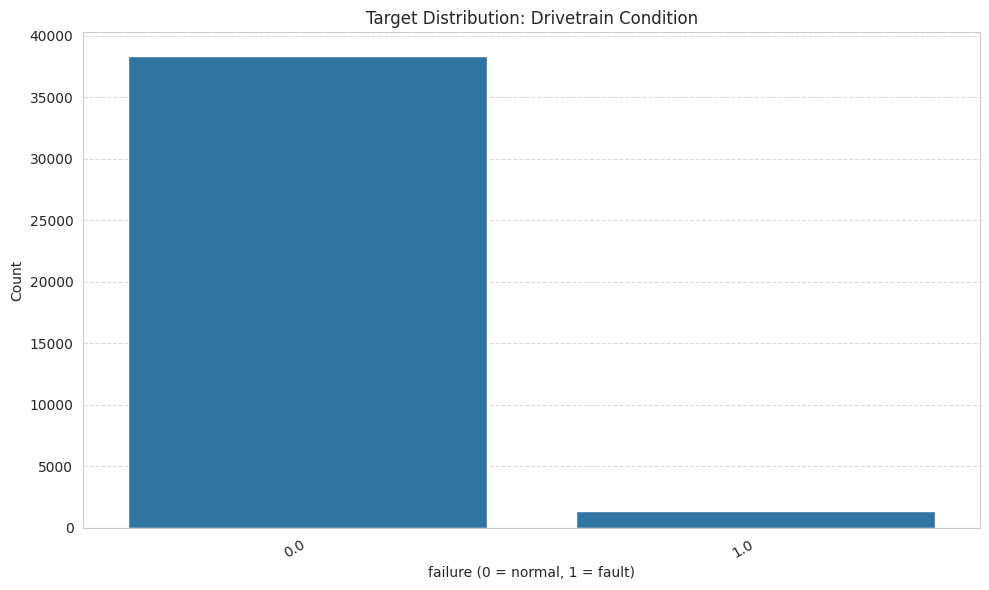

In [ ]:
barchart(data, 'failure', title='Target Distribution: Drivetrain Condition', xlabel='failure (0 = normal, 1 = fault)')

Many more expected failures vs unexpected failures.

### ```wind_speed_mps```

Generate a histogram of the `wind_speed_mps` feature. Identify the range where most observations are concentrated and check for any skewness or unusual values.

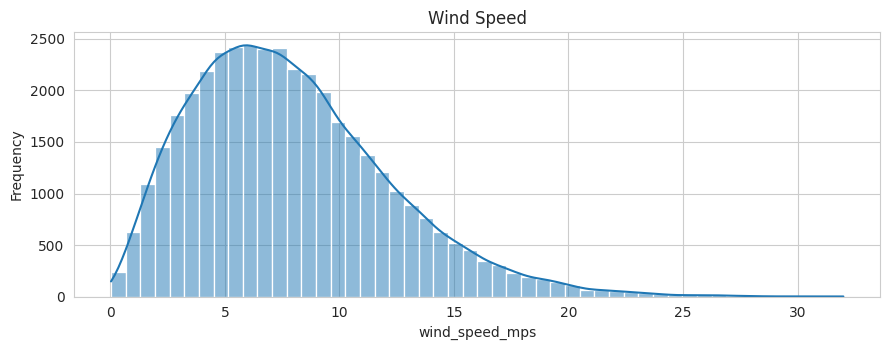

In [ ]:
histogram(data, "wind_speed_mps", title='Wind Speed', xlabel="wind_speed_mps")

Right skewed a bit to the higher wind speeds.  Lower wind speeds are more common.

### ```air_density_kgm3```

Generate a histogram of the `air_density_kgm3` feature. Observe where most air density values are concentrated, assess the spread of the data, and identify any skewness or unusual values.

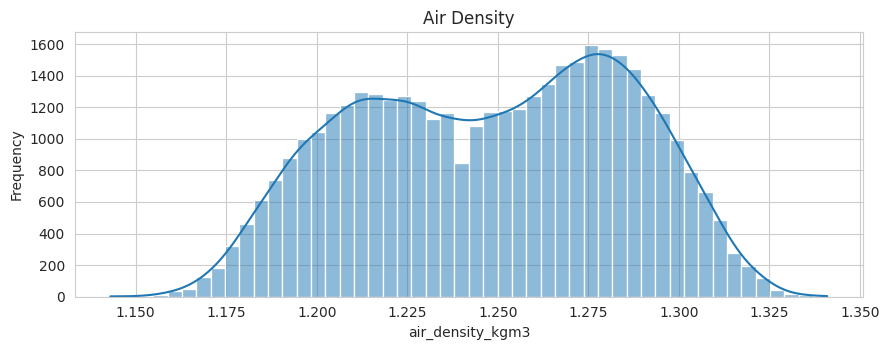

In [ ]:
histogram(data, 'air_density_kgm3', title='Air Density', xlabel='air_density_kgm3' )

Looking at the Air Density histogram we a peaks between 1.2 and 1.28 densities indicating that there may be multiple sources for the data.
The skew isn't convincing indicating the mean and the median values are close.

### ```gearbox_oil_temp_C```

Generate a histogram of the `gearbox_oil_temp_C` feature. Observe where most gearbox oil temperature values are concentrated, assess the spread of the data, and identify any skewness or unusual values.

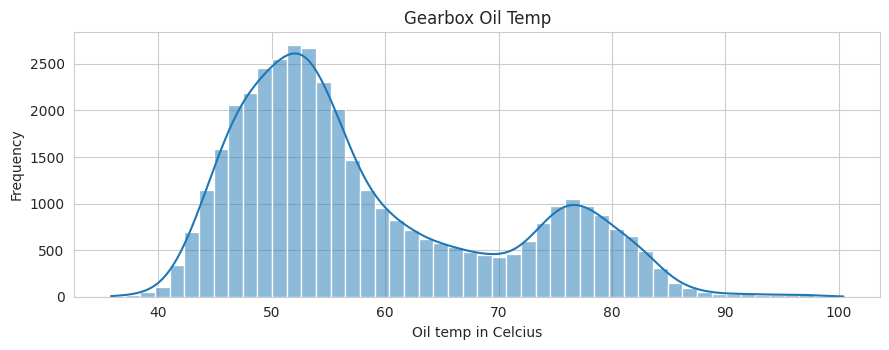

In [ ]:
histogram(data, 'gearbox_oil_temp_C', title='Gearbox Oil Temp', xlabel='Oil temp in Celcius')

We see multiple peaks in the histogram perhaps indicating multiple sources.
Also the skew is slightly to the left indicating the median is greater than the mean.

### ```generator_winding_temp_C```

Generate a histogram of the `generator_winding_temp_C` feature. Observe where most generator winding temperature values are concentrated, assess the spread of the data, and identify any skewness or unusual values.

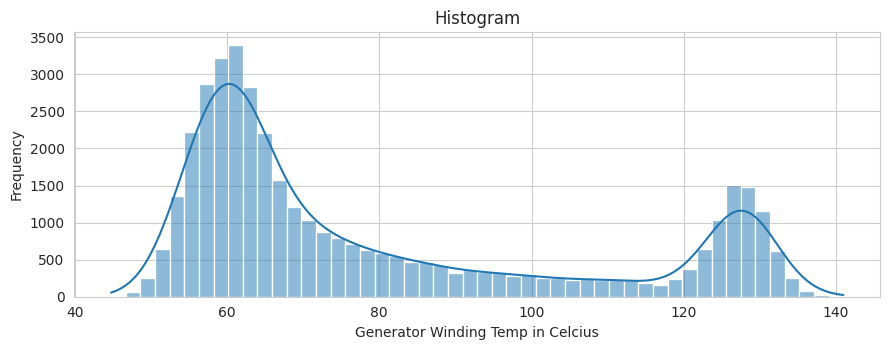

In [ ]:
histogram(data, 'generator_winding_temp_C', xlabel='Generator Winding Temp in Celcius')

There are two peaks spread far apart.  This might indicate again that there are multiple data sources - 2 perhaps with seperate mechanisms.
Skewness is minimal it appears although there are a few values popping up between the two peaks.  This might indicate that each distinct group has it's own mean and median.

### ```drivetrain_vibration_rms_mmps```

Generate a histogram of the `drivetrain_vibration_rms_mmps` feature. Observe where most vibration values are concentrated, assess the spread of the data, and identify any skewness or unusual values.

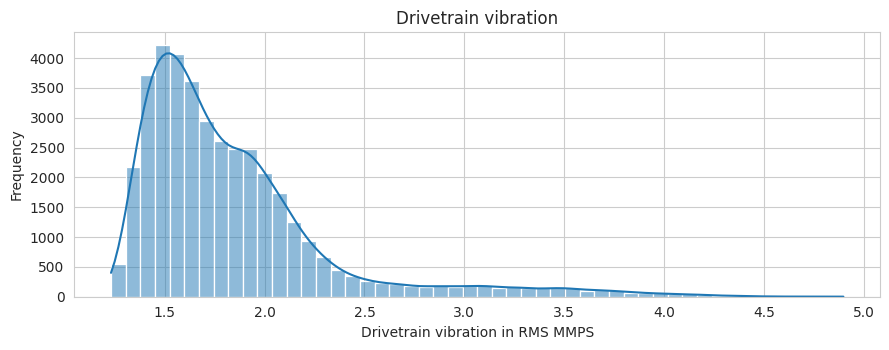

In [ ]:
histogram(data, 'drivetrain_vibration_rms_mmps', title='Drivetrain vibration', xlabel='Drivetrain vibration in RMS MMPS')

Heavy right skewness to the right indicating the mean is greater than the median.  Assuming multiple sources from previous charts it appears that vibration is similar in both sources.

### ```tower_vibration_mmps```

Generate a histogram of the `tower_vibration_mmps` feature. Observe where most tower vibration values are concentrated, assess the spread of the data, and identify any skewness or unusual values.

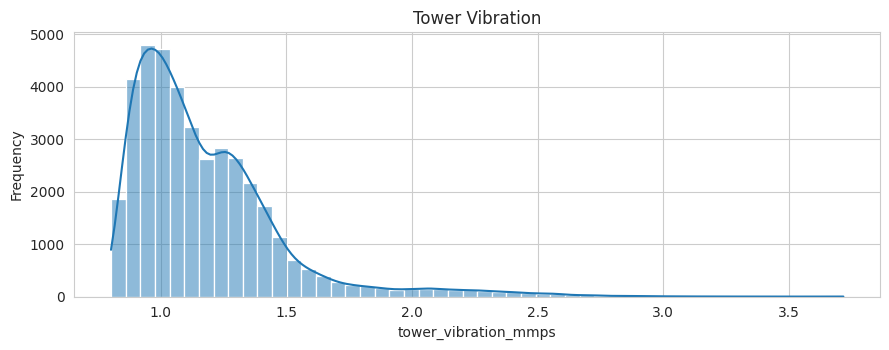

In [ ]:
histogram(data, 'tower_vibration_mmps', title='Tower Vibration', xlabel='tower_vibration_mmps')

Again strong right skewness.  Mean is greater than the median indicating offsetting high frequencies to the lower vibrations.

### ```oil_particle_count```

Generate a histogram of the `oil_particle_count` feature. Observe where most oil particle count values are concentrated, assess the spread of the data, and identify any skewness or unusual values.

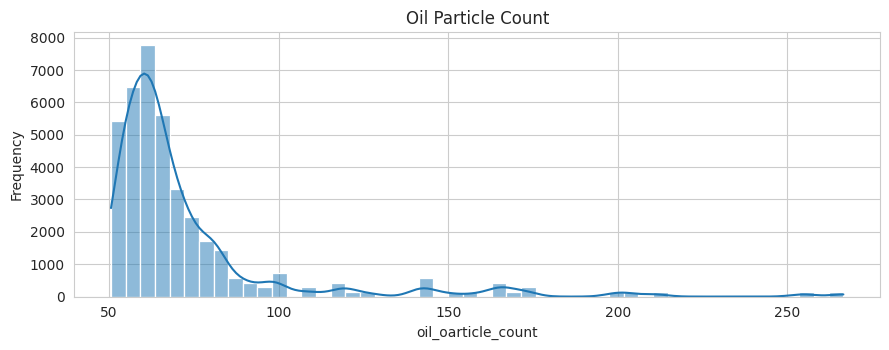

In [ ]:
histogram(data, 'oil_particle_count', title='Oil Particle Count', xlabel='oil_oarticle_count')

Again right skewness with curious outliers in higher values.  Higher particle frequencies are located with lower counts.  Why?

### ```prior_fault_count```

Generate a histogram of the `prior_fault_count` feature. Observe where most prior fault count values are concentrated, assess the spread of the data, and identify any skewness or unusual values.

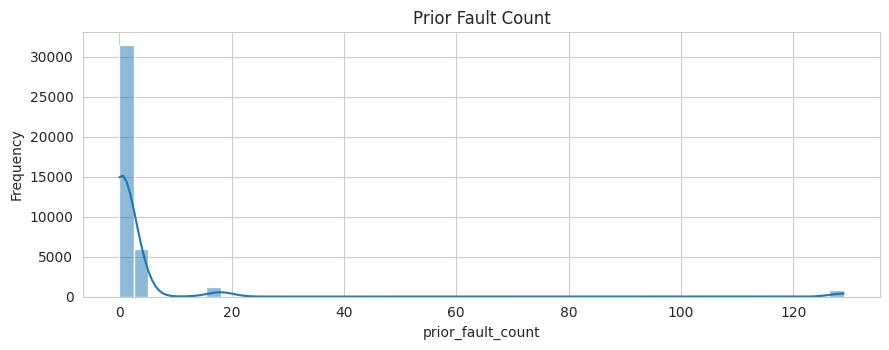

In [ ]:
histogram(data, 'prior_fault_count', title='Prior Fault Count', xlabel='prior_fault_count')

Fault counts look to be pretty high in the low counts but there are a few that occur every so often.

### ```component_age_days```

Generate a histogram of the `component_age_days` feature. Observe where most component age values are concentrated, assess the spread of the data, and identify any skewness or unusual values.

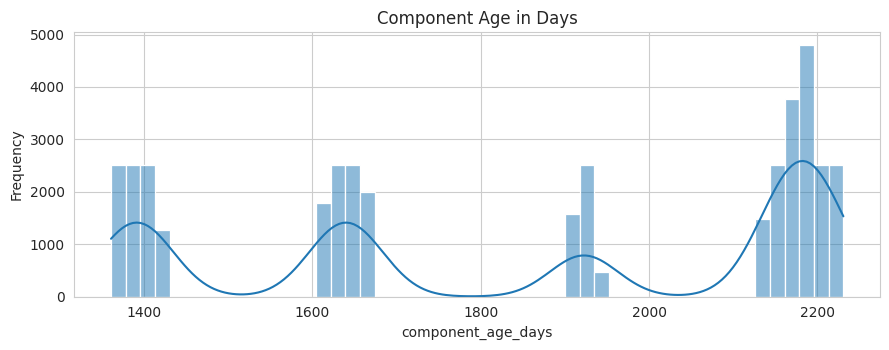

In [ ]:
histogram(data, 'component_age_days', title='Component Age in Days', xlabel='component_age_days')

Multimodal result.  Various groupings.  More components aged around 6 years than any other group

##oil_pressure_bar
Create histogram of oil_pressure_bar so I know how to impute NaN values

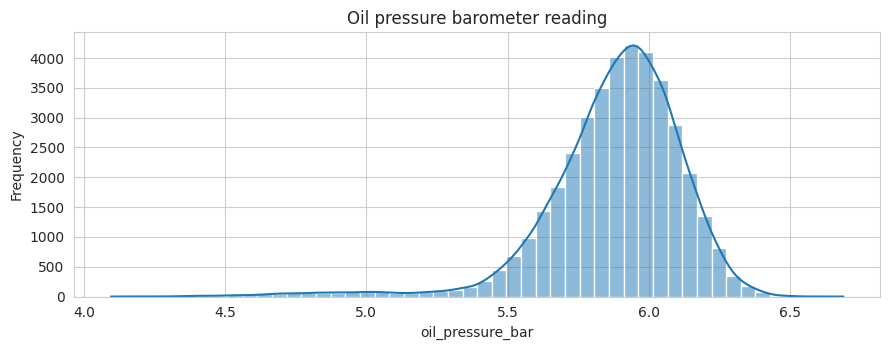

In [ ]:
histogram(data, 'oil_pressure_bar', title='Oil pressure barometer reading', xlabel='oil_pressure_bar')

##generator_bearing_temp_C
Create histogram of generator_bearing_temp_C so I know how to impute.

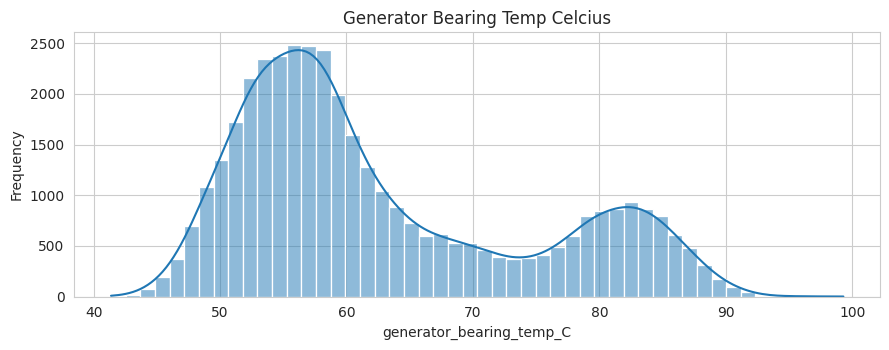

In [ ]:
histogram(data, 'generator_bearing_temp_C', title='Generator Bearing Temp Celcius', xlabel='generator_bearing_temp_C')

##load_cycles
Create histogram of load_cycles so I know how to impute.

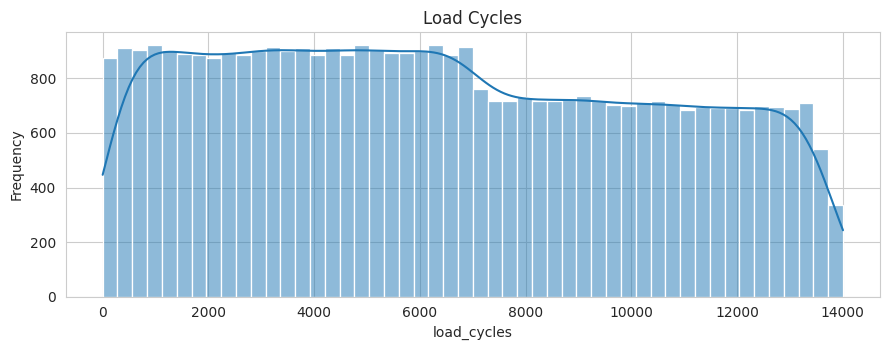

In [ ]:
histogram(data, 'load_cycles', title='Load Cycles', xlabel='load_cycles')

##hours_since_last_maintenance
Create histogram of hours_since_last_maintenance so I know how to impute

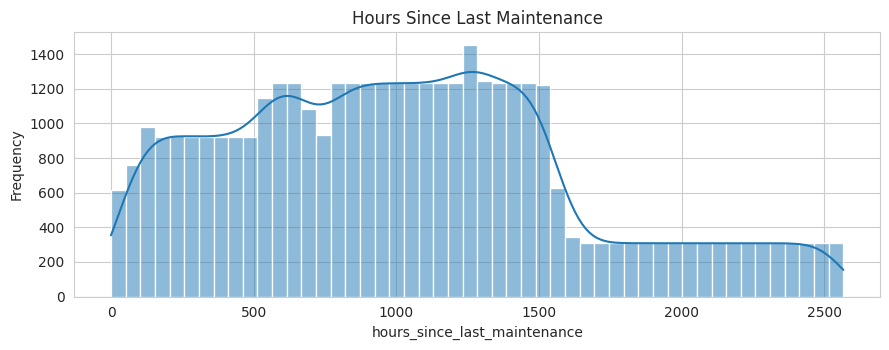

In [ ]:
histogram(data, 'hours_since_last_maintenance', title='Hours Since Last Maintenance', xlabel='hours_since_last_maintenance')

##prior_fault_count
Create histogram for prior_fault_count so I know how to impute

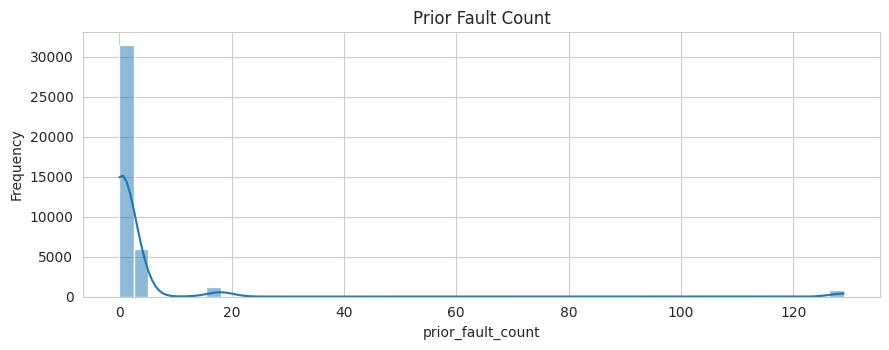

In [ ]:
histogram(data, 'prior_fault_count', title='Prior Fault Count', xlabel='prior_fault_count')

## Bivariate Analysis

### ```turbine_id``` vs ```failure```

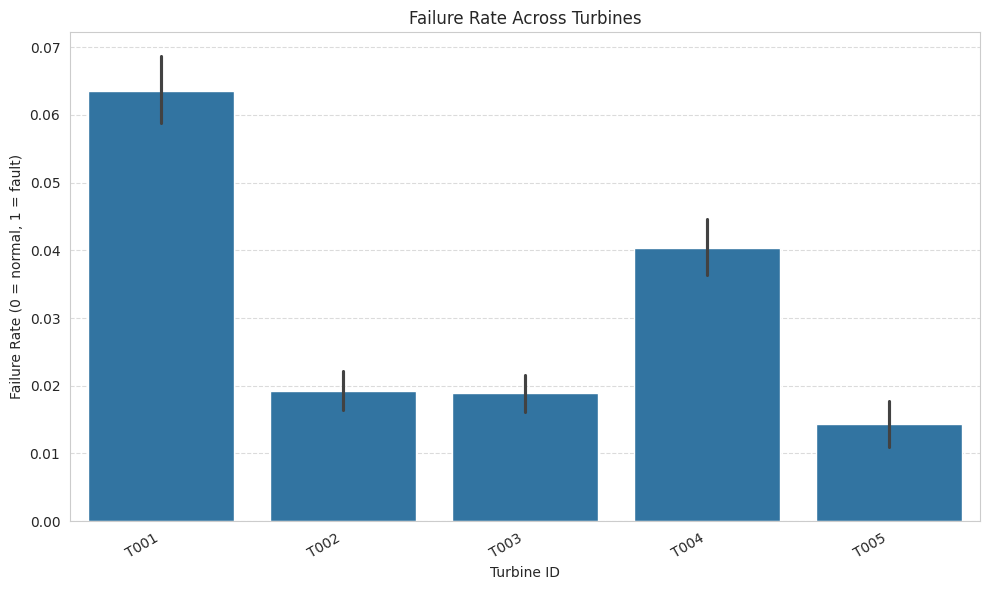

In [ ]:
barchart(data_df=data, x_col='turbine_id', y_col='failure', title='Failure Rate Across Turbines', xlabel='Turbine ID', ylabel='Failure Rate (0 = normal, 1 = fault)')

T001 has the most failures clearly.
More focus should be applied to this turbine.

### `wind_speed_mps` vs `power_output_kW`

Perform the following steps to analyze the relationship between wind speed and power output:

1. Group the `wind_speed_mps` values into intervals (bins).
2. Calculate the average `power_output_kW` for each wind speed interval.
3. Plot the average power output against the wind speed intervals.
4. Observe how power output changes as wind speed increases and identify any trends or patterns.

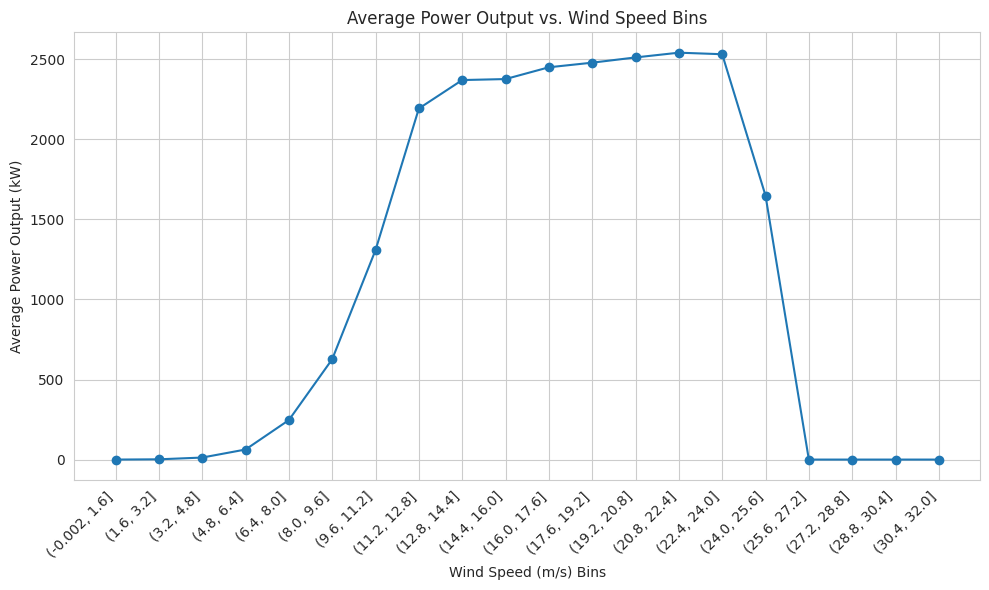

In [ ]:
wind_speed_bins_pd = pd.cut(data['wind_speed_mps'], bins=20, precision=1)
power_output_mean = data.groupby(wind_speed_bins_pd)['power_output_kW'].mean()

plt.figure(figsize=(10, 6))
plt.plot(power_output_mean.index.astype(str), power_output_mean.values, marker='o')
plt.xlabel('Wind Speed (m/s) Bins')
plt.ylabel('Average Power Output (kW)')
plt.title('Average Power Output vs. Wind Speed Bins')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

The data binning shows that most of the power generated happens betwween 11.2 and 24 wind speeds.  Interesting that the higher wind speeds don't generate any power but that's likely because there the wind never hit those speeds.

### ```rotor_speed_rpm``` vs ```generator_speed_rpm```

Generate a scatter plot using `rotor_speed_rpm` and `generator_speed_rpm`. Observe whether a relationship exists between the two variables, identify the overall trend, and look for any unusual observations or outliers.

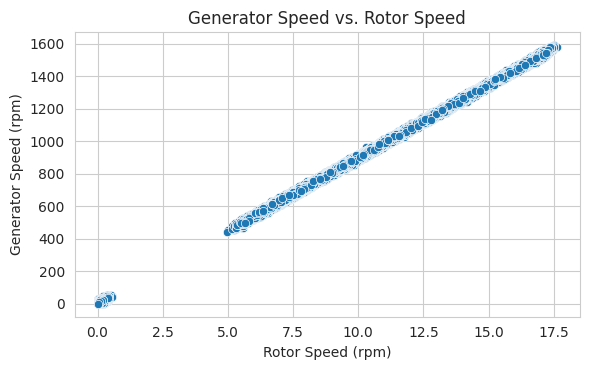

In [ ]:
scatterplot(data, x_col='rotor_speed_rpm', y_col='generator_speed_rpm',
            title='Generator Speed vs. Rotor Speed',
            xlabel='Rotor Speed (rpm)',
            ylabel='Generator Speed (rpm)')

Pretty linear relationship between generator speed and rotor speed which makes sense.  There is a significant gap in the lower rotor speeds, perhaps because those speeds were either not recorded or didn't happen.

### ```wind_speed_mps``` vs ```rotor_speed_rpm```

Generate a scatter plot using `wind_speed_mps` and `rotor_speed_rpm`. Observe how rotor speed changes with increasing wind speed, identify the overall relationship between the two variables, and look for any unusual observations or outliers.

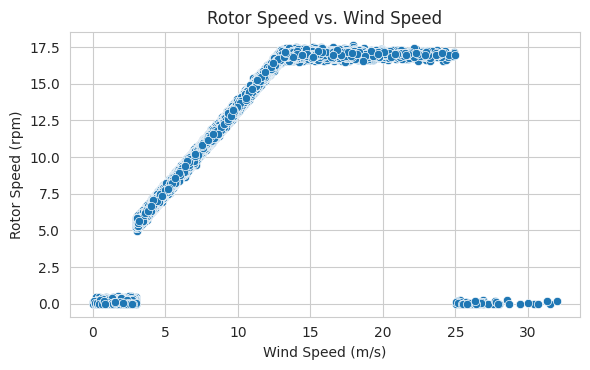

In [ ]:
scatterplot(data, x_col='wind_speed_mps', y_col='rotor_speed_rpm',
            title='Rotor Speed vs. Wind Speed',
            xlabel='Wind Speed (m/s)',
            ylabel='Rotor Speed (rpm)')

Again no data for the same range in rotor speed as the previous plot.  Appears that the rotor speed levels out at wind speed of about 13 m/s.  Might want to put a note of this lack of data for that range

### `drivetrain_vibration_rms_mmps` vs `failure`

Generate a box plot of `drivetrain_vibration_rms_mmps` across the `failure` classes. Compare the distribution of vibration levels between normal and fault conditions, and identify any differences in central tendency, spread, and potential outliers.

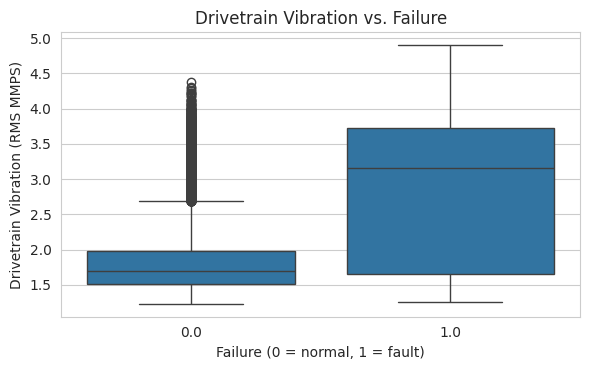

Spread: failure
0.0    0.470
1.0    2.063
Name: drivetrain_vibration_rms_mmps, dtype: float64
Medians: failure
0.0    1.699
1.0    3.159
Name: drivetrain_vibration_rms_mmps, dtype: float64


In [ ]:
from scipy.stats import iqr
boxplot(data, x_col='failure', y_col='drivetrain_vibration_rms_mmps',
        title='Drivetrain Vibration vs. Failure',
        xlabel='Failure (0 = normal, 1 = fault)',
        ylabel='Drivetrain Vibration (RMS MMPS)')

spread = data.groupby('failure')['drivetrain_vibration_rms_mmps'].apply(lambda x: iqr(x))
print('Spread:', spread)

medians = data.groupby('failure')['drivetrain_vibration_rms_mmps'].median()
print(f"Medians: {medians}")

The median for the normal failure box plot is 1.699  The median for the fault failure is 3.159.  These medians indicate the central tendancy for both plots.  The spread of Drive train Vibration is .470 for the normal failures and 2.063 for the fault failures.  Potential outliers are all on the normal failures.  More faults when the drive train vibrations are higher.

### `oil_particle_count` vs `failure`

Generate a box plot of `oil_particle_count` across the `failure` classes. Compare the distribution of oil particle counts between normal and fault conditions, and identify any differences in central tendency, spread, and potential outliers.

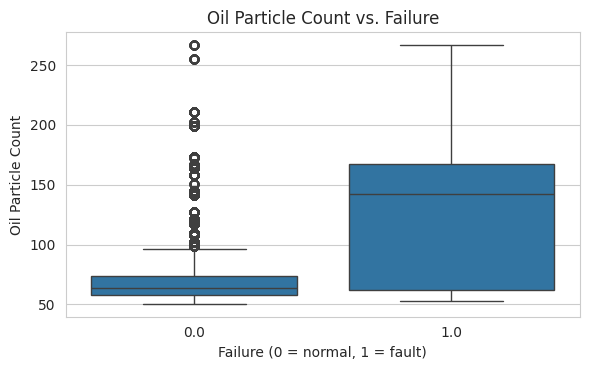

Spread: failure
0.0     15.589
1.0    105.253
Name: oil_particle_count, dtype: float64
Medians: failure
0.0     63.520
1.0    141.934
Name: oil_particle_count, dtype: float64


In [ ]:
boxplot(data, x_col='failure', y_col='oil_particle_count',
        title='Oil Particle Count vs. Failure',
        xlabel='Failure (0 = normal, 1 = fault)',
        ylabel='Oil Particle Count')

spread = data.groupby('failure')['oil_particle_count'].apply(lambda x: iqr(x))
print('Spread:', spread)

medians = data.groupby('failure')['oil_particle_count'].median()
print(f"Medians: {medians}")

Mostly fault failures.  The spread of oil particle count for normal failures is 15.589.  The spread of oil particle count for fault failures is 105.253.  The median for normal failures is 63.52 and the median for fault failures is 141.934.  These medians indicate the central tendency for each bin.
This is important since a higher number of oil particles leads to more faults.

### `gearbox_bearing_temp_C` vs `failure`

Generate a box plot of `gearbox_bearing_temp_C` across the `failure` classes. Compare the distribution of gearbox bearing temperatures between normal and fault conditions, and identify any differences in central tendency, spread, and potential outliers.

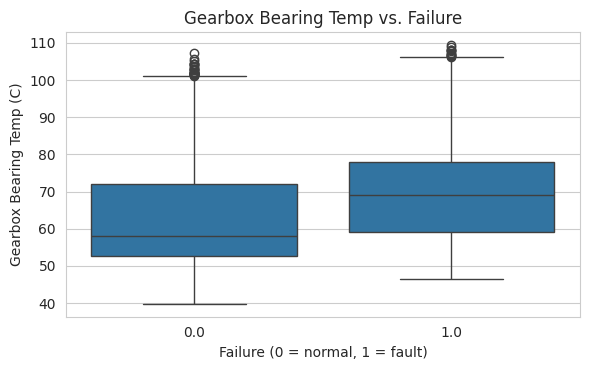

Spread: failure
0.0    19.306
1.0    18.845
Name: gearbox_bearing_temp_C, dtype: float64
Medians: failure
0.0    58.199
1.0    69.099
Name: gearbox_bearing_temp_C, dtype: float64


In [ ]:
boxplot(data, x_col='failure', y_col='gearbox_bearing_temp_C',
        title='Gearbox Bearing Temp vs. Failure',
        xlabel='Failure (0 = normal, 1 = fault)',
        ylabel='Gearbox Bearing Temp (C)')

spread = data.groupby('failure')['gearbox_bearing_temp_C'].apply(lambda x: iqr(x))
print(f'Spread: {spread}')

medians = data.groupby('failure')['gearbox_bearing_temp_C'].median()
print(f"Medians: {medians}")

The spread is very close between the two bins.  19.306 and 18.845.  The central tendancy for normal failures tends towards 58.199 and for fault failures is 69.099.  Fault and normal failures are similar.  This relationship might not be important in the evaluation.

### `power_output_kW` vs `failure`

Generate a box plot of `power_output_kW` across the `failure` classes. Compare the distribution of power output between normal and fault conditions, and identify any differences in central tendency, spread, and potential outliers.

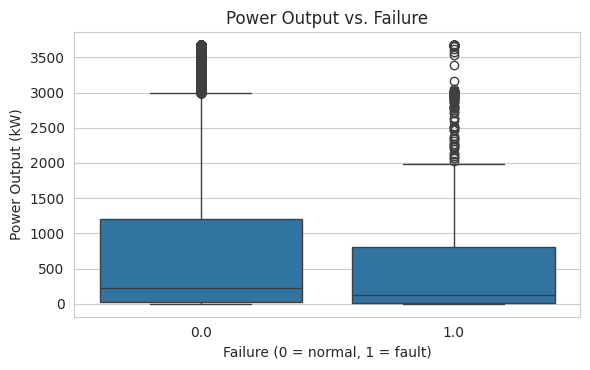

Spread: failure
0.0    1188.098
1.0     794.479
Name: power_output_kW, dtype: float64
Medians: failure
0.0    231.092
1.0    125.083
Name: power_output_kW, dtype: float64


In [ ]:
boxplot(data, x_col='failure', y_col='power_output_kW',
        title='Power Output vs. Failure',
        xlabel='Failure (0 = normal, 1 = fault)',
        ylabel='Power Output (kW)')

gearbox_bearing_temp_C_spread = data.groupby('failure')['power_output_kW'].apply(lambda x: iqr(x))
print(f'Spread: {gearbox_bearing_temp_C_spread}')

medians = data.groupby('failure')['power_output_kW'].median()
print(f"Medians: {medians}")

The distribution of power output between the normal and fault conditions is fairly close with normal faults occuring at about 25% more power output than the fault failures.  The spread of normal failures is 1188.098C with a central tendency towards 231.092C
The spread of fault failures is 794.479 with a tendency toward 123.083C.  Lots of outliers in both bins mostly in the higher power output ranges.  Power output doesn't appear to be that important for the evaluation.

### `prior_fault_count` vs `failure`

Generate a box plot of `prior_fault_count` across the `failure` classes. Compare the distribution of prior fault counts between normal and fault conditions, and identify any differences in central tendency, spread, and potential outliers.

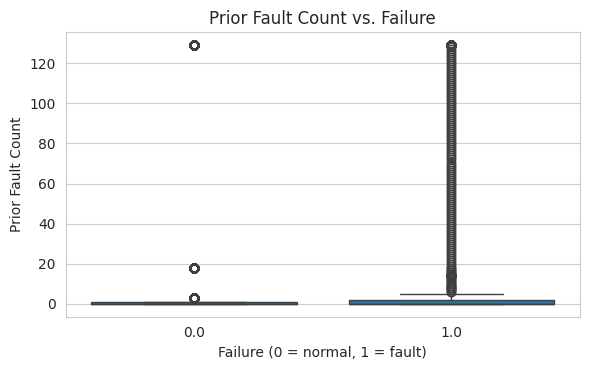

Spread: failure
0.0    1.0
1.0    2.0
Name: prior_fault_count, dtype: float64
Medians: failure
0.0    0.0
1.0    0.0
Name: prior_fault_count, dtype: float64


In [ ]:
boxplot(data, x_col='failure', y_col='prior_fault_count',
        title='Prior Fault Count vs. Failure',
        xlabel='Failure (0 = normal, 1 = fault)',
        ylabel='Prior Fault Count')

spread = data.groupby('failure')['prior_fault_count'].apply(lambda x: iqr(x))
print(f'Spread: {spread}')

medians = data.groupby('failure')['prior_fault_count'].median()
print(f"Medians: {medians}")

For the most part we see outliers in this plot.  The spread for normal failures in only 1.0 and for fault failures only 2.0.  These compact plots tell us the prior fault count is very consistent.  Both of the bins tend toward 0 prior failures.  However there are many more outliers in the faults if there have been prior faults.  This is important in the evaluation.

### ```failure``` vs ```hour```

Perform the following steps to analyze how failure rates vary throughout the day:

1. Calculate the failure rate for each hour of the day.
2. Convert the failure rate into percentage values for easier interpretation.
3. Generate a bar chart to visualize the hourly failure rates.
4. Identify the hours with the highest and lowest failure rates, and observe any time-based patterns in failures.

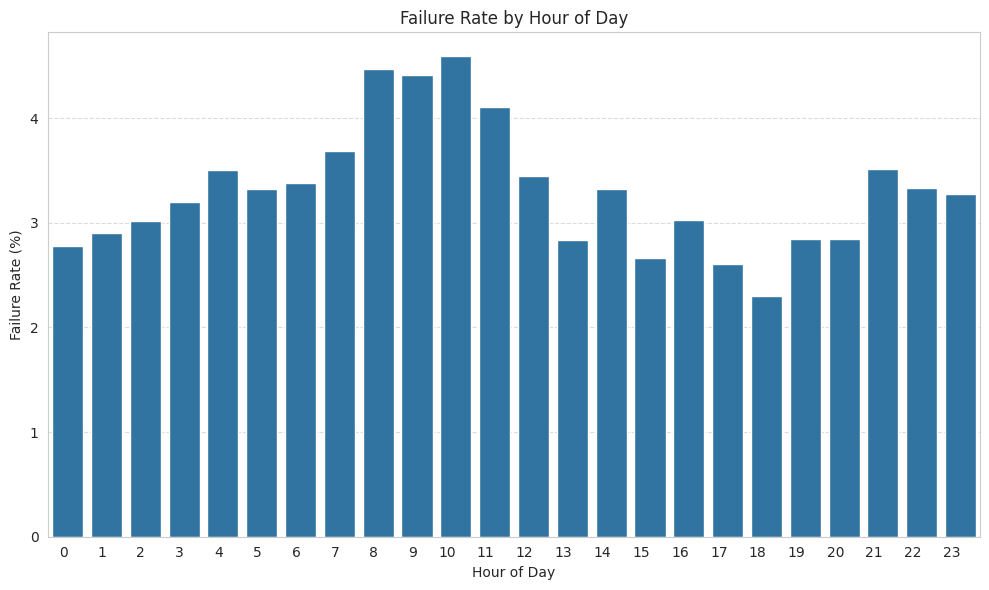

In [ ]:
# Failure rate per hour
failure_rate_by_hour_df = data.groupby('hour')['failure'].mean().reset_index()

failure_rate_by_hour_df['failure_rate_pct'] = failure_rate_by_hour_df['failure'] * 100

# Plot using the barchart utility function
barchart(data_df=failure_rate_by_hour_df, x_col='hour', y_col='failure_rate_pct',
         title='Failure Rate by Hour of Day',
         xlabel='Hour of Day', ylabel='Failure Rate (%)', rot_degrees=0)

Failures look pretty consitent across hours with peaks in the morning.  More activity then it appears.  Not that important in the evaluation.

### ```failure``` vs ```dayofweek```

Perform the following steps to analyze how failure rates vary across the days of the week:

1. Calculate the failure rate for each day of the week.
2. Convert the failure rate into percentage values for easier interpretation.
3. Arrange the days in chronological order from Monday to Sunday.
4. Generate a bar chart to visualize the failure rates across the week.
5. Identify the days with the highest and lowest failure rates, and observe any weekly patterns in failures.

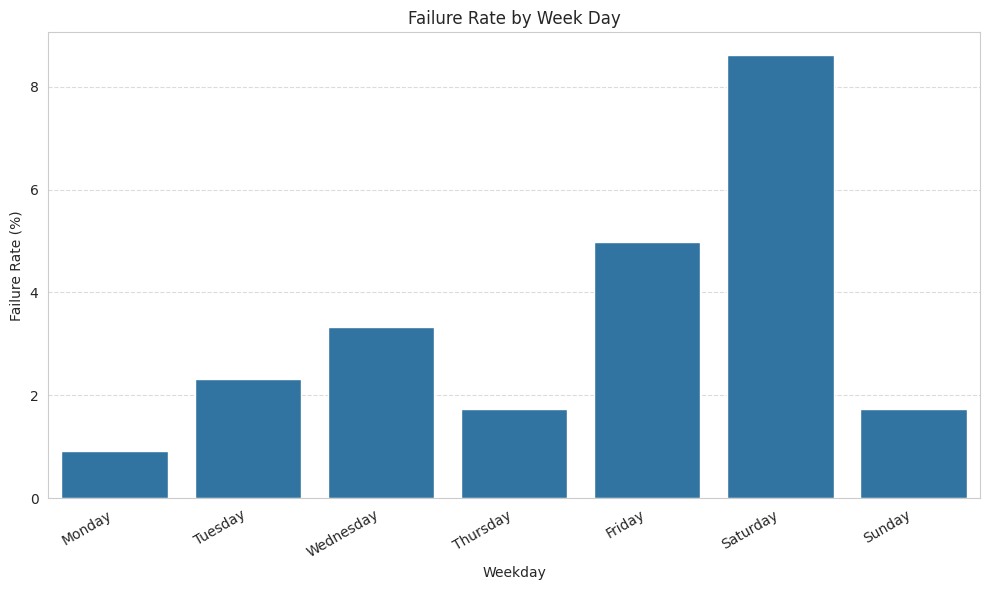

In [ ]:
failure_rate_per_weekday_df = data.groupby('dayofweek')['failure'].mean().reset_index()
failure_rate_per_weekday_df['failure_rate_pct'] = failure_rate_per_weekday_df['failure'] * 100
# Define the chronological order of days for sorting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Map numerical dayofweek to names
day_name_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
failure_rate_per_weekday_df['dayofweek'] = failure_rate_per_weekday_df['dayofweek'].map(day_name_map)

# Convert 'dayofweek' to a categorical type with the defined order
failure_rate_per_weekday_df['dayofweek'] = pd.Categorical(failure_rate_per_weekday_df['dayofweek'], categories=day_order, ordered=True)

# Sort the DataFrame by the ordered 'dayofweek'
failure_rate_per_weekday_df = failure_rate_per_weekday_df.sort_values('dayofweek')

barchart(data_df=failure_rate_per_weekday_df, x_col='dayofweek', y_col='failure_rate_pct',
         title='Failure Rate by Week Day',
         xlabel='Weekday', ylabel='Failure Rate (%)', rot_degrees=30)

More fails on Satuday.

##yaw_misalignment_deg vs failure

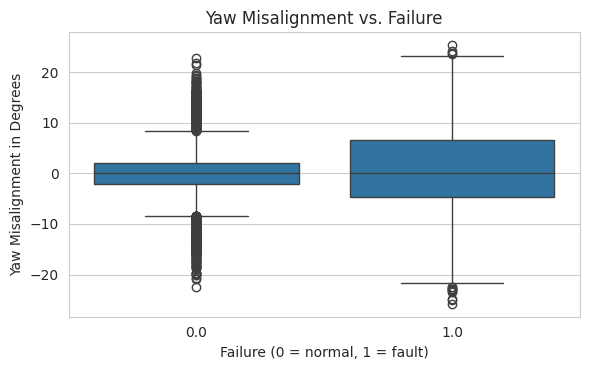

Medians: failure
0.0   -0.006
1.0    0.060
Name: yaw_misalignment_deg, dtype: float64


In [ ]:
boxplot(data, x_col='failure', y_col='yaw_misalignment_deg',
        title='Yaw Misalignment vs. Failure',
        xlabel='Failure (0 = normal, 1 = fault)',
        ylabel='Yaw Misalignment in Degrees')

medians = data.groupby('failure')['yaw_misalignment_deg'].median()
print(f"Medians: {medians}")


##Drivetrain vibrations vs Failure

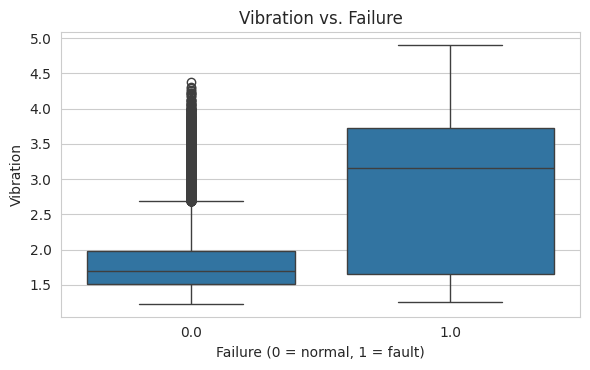

Medians: failure
0.0    1.699
1.0    3.159
Name: drivetrain_vibration_rms_mmps, dtype: float64


In [ ]:
boxplot(data, x_col='failure', y_col='drivetrain_vibration_rms_mmps',
        title='Vibration vs. Failure',
        xlabel='Failure (0 = normal, 1 = fault)',
        ylabel='Vibration')

medians = data.groupby('failure')['drivetrain_vibration_rms_mmps'].median()
print(f"Medians: {medians}")

##Tower Vibration vs Failure

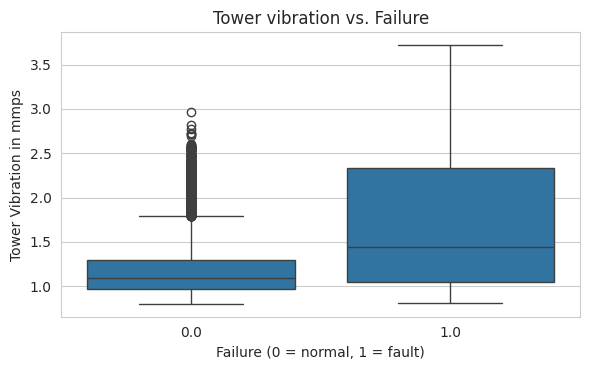

Medians: failure
0.0    1.095
1.0    1.437
Name: tower_vibration_mmps, dtype: float64


In [ ]:
boxplot(data, x_col='failure', y_col='tower_vibration_mmps',
        title='Tower vibration vs. Failure',
        xlabel='Failure (0 = normal, 1 = fault)',
        ylabel='Tower Vibration in mmps')

medians = data.groupby('failure')['tower_vibration_mmps'].median()
print(f"Medians: {medians}")

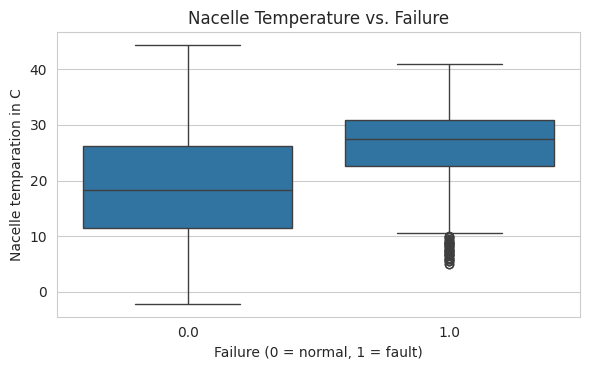

Medians: failure
0.0    18.337
1.0    27.419
Name: nacelle_temp_C, dtype: float64


In [ ]:
boxplot(data, x_col='failure', y_col='nacelle_temp_C',
        title='Nacelle Temperature vs. Failure',
        xlabel='Failure (0 = normal, 1 = fault)',
        ylabel='Nacelle temparation in C')

medians = data.groupby('failure')['nacelle_temp_C'].median()
print(f"Medians: {medians}")

## Multivariate Analysis

### Correlation Analysis

Create a list of all numerical features that will be used for correlation analysis. These features will be used to examine relationships between numerical variables and identify patterns that may be useful for further analysis and model building.

In [ ]:
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
display(numeric_cols)

['rated_power_kW',
 'wind_speed_mps',
 'wind_direction_deg',
 'turbulence_intensity',
 'air_density_kgm3',
 'ambient_temp_C',
 'humidity_pct',
 'power_output_kW',
 'rotor_speed_rpm',
 'generator_speed_rpm',
 'blade_pitch_angle_deg',
 'yaw_misalignment_deg',
 'gearbox_oil_temp_C',
 'gearbox_bearing_temp_C',
 'generator_bearing_temp_C',
 'generator_winding_temp_C',
 'main_bearing_temp_C',
 'nacelle_temp_C',
 'drivetrain_vibration_rms_mmps',
 'tower_vibration_mmps',
 'vib_fft_bearing_bpfo',
 'vib_fft_bearing_bpfi',
 'vib_fft_gearmesh',
 'vib_fft_sideband',
 'oil_particle_count',
 'oil_pressure_bar',
 'operating_hours_total',
 'cumulative_energy_MWh',
 'load_cycles',
 'hours_since_last_maintenance',
 'prior_fault_count',
 'component_age_days',
 'failure',
 'dayofweek',
 'hour']

Generate a correlation matrix for the numerical features. Examine the strength and direction of relationships between variables, identify highly correlated feature pairs, and look for potential multicollinearity that may affect model performance.

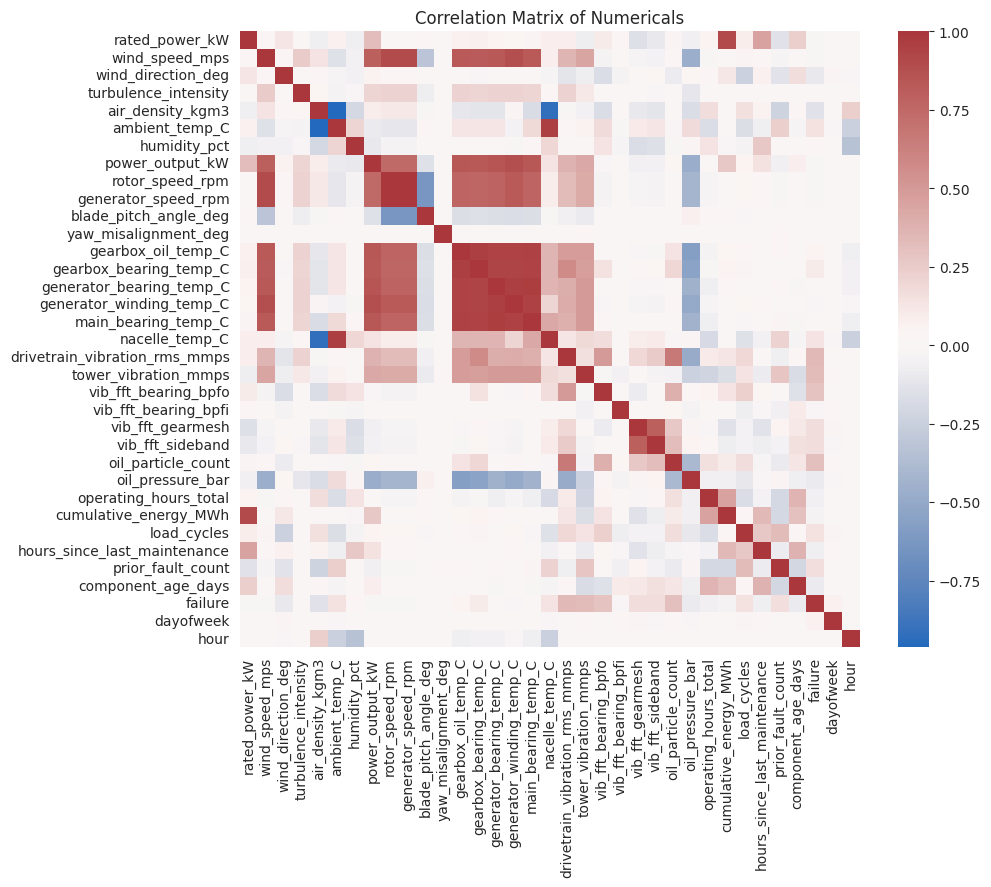

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[numeric_cols].corr(), annot=False, cmap='vlag', fmt=".2f")
plt.title('Correlation Matrix of Numericals')
plt.show()

High correllation between wind speed and power output, rotor speed, and generator speed.  Also between wind speed and gearbox oil temp, gearbox bearing temp, generator bearing temp, generator winding temp and main bearing temp.

Also there is a high correllation between nacelle temp and ambiant temp.

Also a high correllation between rated power in KWh and cumulative energy in MWh

# **Data Preprocessing**

## Splitting the data into train, validation, and test sets

This data is **panel time-series**: 15 turbines, each logged every 10 minutes over two months, and a single degradation episode spans many consecutive rows. A random split would scatter rows from the same episode across train and test, letting the model effectively see failures it is later scored on - inflating every metric.


In [ ]:
data = data.sort_values(by=['timestamp','turbine_id'])

In [ ]:
nan_rows = data[data.isna().any(axis=1)]
print(nan_rows)

                timestamp turbine_id  rated_power_kW  wind_speed_mps  \
35146 2024-01-01 01:40:00       T005            1500          12.765   
17596 2024-01-01 04:40:00       T003            3600          11.261   
26382 2024-01-01 05:00:00       T004            3000           7.404   
8824  2024-01-01 06:40:00       T002            1500           6.388   
26392 2024-01-01 06:40:00       T004            3000          10.345   
...                   ...        ...             ...             ...   
8702  2024-03-01 10:20:00       T001            1500          10.534   
8733  2024-03-01 15:30:00       T001            1500           3.428   
17525 2024-03-01 16:50:00       T002            1500           1.093   
17529 2024-03-01 17:30:00       T002            1500          15.160   
17543 2024-03-01 19:50:00       T002            1500          12.190   

       wind_direction_deg  turbulence_intensity  air_density_kgm3  \
35146              51.970                 0.172             1.213 

In [ ]:
n = len(data)
print(n)

39689


In [ ]:
# Uncomment the below train and validation indices to create a 70% train, 15% validation, and 15% test split.
i_train = int(n * 0.70)
i_val = int(n * 0.85)

print(f'Train split: {i_train}')
print(f'Validation split: {i_val}')

# Uncomment the below train and validation indices to create a 90% train, 5% validation, and 5% test split.
# i_train = int(n * 0.90)
# i_val = int(n * 0.95)

# Uncomment the below train and validation indices to create a 80% train, 10% validation, and 10% test split.
# i_train = int(n * 0.80)
# i_val = int(n * 0.90)

Train split: 27782
Validation split: 33735


In [ ]:
data_train = data.iloc[:i_train]
data_val = data.iloc[i_train:i_val]
data_test = data.iloc[i_val:]

x_train = data_train.drop(columns=['failure', 'timestamp', 'turbine_id'])
y_train = data_train['failure']

x_valid = data_val.drop(columns=['failure', 'timestamp', 'turbine_id'])
y_valid = data_val['failure']

x_test = data_test.drop(columns=['failure', 'timestamp', 'turbine_id'])
y_test = data_test['failure']

In [ ]:
# See which columns have NaN values after the split
x_train.columns[x_train.isna().any()].tolist()
# y_train is a series so this doesn't work
# y_train.columns[y_train.isna().any()].tolist()

['gearbox_oil_temp_C',
 'generator_bearing_temp_C',
 'oil_pressure_bar',
 'load_cycles',
 'hours_since_last_maintenance',
 'prior_fault_count',
 'component_age_days']

In [ ]:
x_valid.columns[x_valid.isna().any()].tolist()

['gearbox_oil_temp_C', 'generator_bearing_temp_C', 'oil_pressure_bar']

In [ ]:
x_test.columns[x_test.isna().any()].tolist()

['gearbox_oil_temp_C', 'generator_bearing_temp_C', 'oil_pressure_bar']

In [ ]:
# Remove Nan from y
print (y_train.shape)
y_train = y_train.fillna(0)
print (y_train.shape)
print (y_valid.shape)
y_valid = y_valid.fillna(0)
print (y_valid.shape)
print (y_test.shape)
y_test = y_test.fillna(0)
print (y_test.shape)

(27782,)
(27782,)
(5953,)
(5953,)
(5954,)
(5954,)


In [ ]:
print(f'Train split failure rate: {y_train.mean()*100:.2f}%')
print(f'Validation split failure rate: {y_valid.mean()*100:.2f}%')
print(f'Test split failure rate: {y_test.mean()*100:.2f}%')

Train split failure rate: 1.49%
Validation split failure rate: 2.40%
Test split failure rate: 12.71%


The failure rate after the split is troubling. I suppose I'll have to account for that.  I can't drop these columns so I'll have to fill in with zero or something else.

## Missing Value Treatment

### Display the percentage of missing values

Check the percentage of missing values in the training, validation, and test datasets. Identify the features with missing values before selecting an appropriate imputation strategy.

In [ ]:
x_train_missing = x_train.isna().mean() * 100
y_train_missing = y_train.isna().mean() * 100
x_valid_missing = x_valid.isna().mean() * 100
y_valid_missing = y_valid.isna().mean() * 100
x_test_missing = x_test.isna().mean() * 100
y_test_missing = y_test.isna().mean() * 100

print(((x_train.isnull().sum() / len(x_train) * 100).round(2)).loc[lambda x: x > 0])

print('x_train')
print(x_train_missing)
print('end x_train')
print('x_valid')
print(x_valid_missing)
print('end x_valid')
print('x_test')
print(x_test_missing)
print('end x_test')

gearbox_oil_temp_C          0.53
generator_bearing_temp_C    0.49
oil_pressure_bar            0.44
dtype: float64
x_train
rated_power_kW                   0.000000
wind_speed_mps                   0.000000
wind_direction_deg               0.000000
turbulence_intensity             0.000000
air_density_kgm3                 0.000000
ambient_temp_C                   0.000000
humidity_pct                     0.000000
power_output_kW                  0.000000
rotor_speed_rpm                  0.000000
generator_speed_rpm              0.000000
blade_pitch_angle_deg            0.000000
yaw_misalignment_deg             0.000000
gearbox_oil_temp_C               0.529120
gearbox_bearing_temp_C           0.000000
generator_bearing_temp_C         0.493125
generator_winding_temp_C         0.000000
main_bearing_temp_C              0.000000
nacelle_temp_C                   0.000000
drivetrain_vibration_rms_mmps    0.000000
tower_vibration_mmps             0.000000
vib_fft_bearing_bpfo             0.000

The percentage missing is obvious in the table.  Two fields are missing a percentage in x_train, three in x_valid, and three in x_test.  After dropping those rows with NaN the percentage is zero

### `gearbox_oil_temp_C`

Perform the following steps to handle missing values in the `gearbox_oil_temp_C` feature:

1. Choose an imputation strategy (`mean`, `median`, or `mode`) based on the distribution of the feature.
2. Calculate the selected statistic using only the training data.
3. Use the calculated value to fill the missing values in the training, validation, and test datasets.
4. Apply the same imputation value across all three datasets to ensure a consistent preprocessing strategy and prevent data leakage.

Note:  Gearbox oil temp has two peaks in the histogram so using KNN to impute

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
x_train['gearbox_oil_temp_C'] = imputer.fit_transform(x_train[['gearbox_oil_temp_C']])
display(x_train['gearbox_oil_temp_C'])
# x_train['gearbox_oil_temp_C'] = x_train['gearbox_oil_temp_C'].fillna(x_train['gearbox_oil_temp_C'].mode()[0])
display(x_train['gearbox_oil_temp_C'])
#display(x_valid['gearbox_oil_temp_C'])
x_valid['gearbox_oil_temp_C'] = imputer.fit_transform(x_valid[['gearbox_oil_temp_C']])
#display(x_valid['gearbox_oil_temp_C'])
display(x_test['gearbox_oil_temp_C'])
x_test['gearbox_oil_temp_C'] = imputer.fit_transform(x_test[['gearbox_oil_temp_C']])
display(x_test['gearbox_oil_temp_C'])

,gearbox_oil_temp_C
0,53.728
8784,75.600
17568,53.901
26352,53.313
35136,51.343
...,...
5806,46.824
14590,79.776
23374,55.351
32158,53.180


,gearbox_oil_temp_C
0,53.728
8784,75.600
17568,53.901
26352,53.313
35136,51.343
...,...
5806,46.824
14590,79.776
23374,55.351
32158,53.180


,gearbox_oil_temp_C
24863,74.205
33647,59.485
7296,48.015
16080,52.754
24864,74.655
...,...
35134,79.462
8783,57.028
17567,47.739
26351,79.634


,gearbox_oil_temp_C
24863,74.205
33647,59.485
7296,48.015
16080,52.754
24864,74.655
...,...
35134,79.462
8783,57.028
17567,47.739
26351,79.634


In [ ]:
x_train.columns[x_train.isna().any()].tolist()

['generator_bearing_temp_C',
 'oil_pressure_bar',
 'load_cycles',
 'hours_since_last_maintenance',
 'prior_fault_count',
 'component_age_days']

In [ ]:
x_valid.columns[x_valid.isna().any()].tolist()

['generator_bearing_temp_C', 'oil_pressure_bar']

In [ ]:
x_test.columns[x_test.isna().any()].tolist()

['generator_bearing_temp_C', 'oil_pressure_bar']

### ```generator_bearing_temp_C```

Perform the following steps to handle missing values in the `generator_bearing_temp_C` feature:

1. Choose an imputation strategy (`mean`, `median`, or `mode`) based on the distribution of the feature.
2. Calculate the selected statistic using only the training data.
3. Use the calculated value to fill the missing values in the training, validation, and test datasets.
4. Apply the same imputation value across all three datasets to ensure a consistent preprocessing strategy and prevent data leakage.

Note:  Using KNN to impute because generator_bearing_temp_C has two peaks.

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
display(x_train['generator_bearing_temp_C'])
x_train['generator_bearing_temp_C'] = imputer.fit_transform(x_train[['generator_bearing_temp_C']])
display(x_train['generator_bearing_temp_C'])
display(x_valid['generator_bearing_temp_C'])
x_valid['generator_bearing_temp_C'] = imputer.fit_transform(x_valid[['generator_bearing_temp_C']])
display(x_valid['generator_bearing_temp_C'])
display(x_test['generator_bearing_temp_C'])
x_test['generator_bearing_temp_C'] = imputer.fit_transform(x_test[['generator_bearing_temp_C']])
display(x_test['generator_bearing_temp_C'])


,generator_bearing_temp_C
0,57.637
8784,80.600
17568,58.500
26352,57.293
35136,55.550
...,...
5806,52.839
14590,86.262
23374,59.417
32158,55.866


,generator_bearing_temp_C
0,57.637
8784,80.600
17568,58.500
26352,57.293
35136,55.550
...,...
5806,52.839
14590,86.262
23374,59.417
32158,55.866


,generator_bearing_temp_C
14591,56.408
23375,50.729
32159,56.762
5808,52.112
14592,59.941
...,...
16078,49.085
24862,49.986
33646,86.484
7295,52.194


,generator_bearing_temp_C
14591,56.408
23375,50.729
32159,56.762
5808,52.112
14592,59.941
...,...
16078,49.085
24862,49.986
33646,86.484
7295,52.194


,generator_bearing_temp_C
24863,80.824
33647,67.405
7296,50.617
16080,57.479
24864,81.285
...,...
35134,90.761
8783,59.987
17567,50.919
26351,85.491


,generator_bearing_temp_C
24863,80.824
33647,67.405
7296,50.617
16080,57.479
24864,81.285
...,...
35134,90.761
8783,59.987
17567,50.919
26351,85.491


In [ ]:
x_train.columns[x_train.isna().any()].tolist()

['oil_pressure_bar',
 'load_cycles',
 'hours_since_last_maintenance',
 'prior_fault_count',
 'component_age_days']

In [ ]:
x_valid.columns[x_valid.isna().any()].tolist()

['oil_pressure_bar']

In [ ]:
x_test.columns[x_test.isna().any()].tolist()

['oil_pressure_bar']

### ```oil_pressure_bar```

Perform the following steps to handle missing values in the `oil_pressure_bar` feature:

1. Choose an imputation strategy (`mean`, `median`, or `mode`) based on the distribution of the feature.
2. Calculate the selected statistic using only the training data.
3. Use the calculated value to fill the missing values in the training, validation, and test datasets.
4. Apply the same imputation value across all three datasets to ensure a consistent preprocessing strategy and prevent data leakage.

Note:  Using median since it's the data is left skewed.

In [ ]:
display(x_train['oil_pressure_bar'])
x_train['oil_pressure_bar'] = x_train['oil_pressure_bar'].fillna(x_train['oil_pressure_bar'].median())
display(x_train['oil_pressure_bar'])
oil_pressure_bar_median = x_train['oil_pressure_bar'].median()
print(oil_pressure_bar_median)

display(x_valid['oil_pressure_bar'])
x_valid['oil_pressure_bar'] = x_valid['oil_pressure_bar'].fillna(oil_pressure_bar_median)
display(x_valid['oil_pressure_bar'])
display(x_test['oil_pressure_bar'])
x_test['oil_pressure_bar'] = x_test['oil_pressure_bar'].fillna(oil_pressure_bar_median)
display(x_test['oil_pressure_bar'])

,oil_pressure_bar
0,6.032
8784,5.669
17568,5.945
26352,6.167
35136,5.936
...,...
5806,5.946
14590,5.833
23374,5.784
32158,5.792


,oil_pressure_bar
0,6.032
8784,5.669
17568,5.945
26352,6.167
35136,5.936
...,...
5806,5.946
14590,5.833
23374,5.784
32158,5.792


5.917


,oil_pressure_bar
14591,6.210
23375,6.073
32159,5.942
5808,5.827
14592,5.947
...,...
16078,5.912
24862,5.943
33646,5.414
7295,5.965


,oil_pressure_bar
14591,6.210
23375,6.073
32159,5.942
5808,5.827
14592,5.947
...,...
16078,5.912
24862,5.943
33646,5.414
7295,5.965


,oil_pressure_bar
24863,5.327
33647,5.877
7296,5.925
16080,5.932
24864,5.669
...,...
35134,5.703
8783,6.107
17567,6.254
26351,5.683


,oil_pressure_bar
24863,5.327
33647,5.877
7296,5.925
16080,5.932
24864,5.669
...,...
35134,5.703
8783,6.107
17567,6.254
26351,5.683


In [ ]:
x_train.columns[x_train.isna().any()].tolist()

['load_cycles',
 'hours_since_last_maintenance',
 'prior_fault_count',
 'component_age_days']

In [ ]:
x_valid.columns[x_valid.isna().any()].tolist()

[]

In [ ]:
x_test.columns[x_test.isna().any()].tolist()

[]

##Impute the rest of the missing values from x_train
component_age_days, load_cycles, hours_since_last_maintenance, prior_fault_count

In [ ]:
from sklearn.impute import KNNImputer

# Using KNN since there are four peaks in this column
imputer = KNNImputer(n_neighbors=5)
print('x_component_age_days')
#x_train['component_age_days'] = x_train['component_age_days'].fillna(x_train['component_age_days'].mode()[0]
display(x_train['component_age_days'])
x_train['component_age_days'] = imputer.fit_transform(x_train[['component_age_days']])
display(x_train['component_age_days'])
display(x_valid['component_age_days'])
x_valid['component_age_days'] = imputer.fit_transform(x_valid[['component_age_days']])
display(x_valid['component_age_days'])
display(x_test['component_age_days'])
x_test['component_age_days'] = imputer.fit_transform(x_test[['component_age_days']])
display(x_test['component_age_days'])

# Using mean since histogram indicates one single peak across all values
print('x_load_cyles')
x_train['load_cycles'] = x_train['load_cycles'].fillna(x_train['load_cycles'].mean())
x_train_load_mean = x_train['load_cycles'].mean()
print(x_train_load_mean)
x_valid['load_cycles'] = x_valid['load_cycles'].fillna(x_train_load_mean)
x_test['load_cycles'] = x_test['load_cycles'].fillna(x_train_load_mean)

# Using mean since histogram indicates one single peak across all values
print('x_hours_since_last_maintenance')
x_train['hours_since_last_maintenance'] = x_train['hours_since_last_maintenance'].fillna(x_train['hours_since_last_maintenance'].mean())
x_train_hours_mean = x_train['hours_since_last_maintenance'].mean()
print(x_train_hours_mean)
x_valid['hours_since_last_maintenance'] = x_valid['hours_since_last_maintenance'].fillna(x_train_hours_mean)
x_test['hours_since_last_maintenance'] = x_test['hours_since_last_maintenance'].fillna(x_train_hours_mean)

# Using mean since histogram indicates right skewed
print('x_prior_fault_count')
x_train['prior_fault_count'] = x_train['prior_fault_count'].fillna(x_train['prior_fault_count'].mean())
x_train_fault_mean = x_train['prior_fault_count'].mean()
print(x_train_fault_mean)
x_valid['prior_fault_count'] = x_valid['prior_fault_count'].fillna(x_train_fault_mean)
x_test['prior_fault_count'] = x_test['prior_fault_count'].fillna(x_train_fault_mean)





x_component_age_days


,component_age_days
0,1360.703
8784,2169.811
17568,2133.545
26352,1609.381
35136,1906.679
...,...
5806,1401.023
14590,2210.130
23374,2173.864
32158,1649.701


,component_age_days
0,1360.703
8784,2169.811
17568,2133.545
26352,1609.381
35136,1906.679
...,...
5806,1401.023
14590,2210.130
23374,2173.864
32158,1649.701


,component_age_days
14591,2210.137
23375,2173.871
32159,1649.707
5808,1401.037
14592,2210.144
...,...
16078,2220.463
24862,2184.197
33646,1660.034
7295,1411.363


,component_age_days
14591,2210.137
23375,2173.871
32159,1649.707
5808,1401.037
14592,2210.144
...,...
16078,2220.463
24862,2184.197
33646,1660.034
7295,1411.363


,component_age_days
24863,2184.204
33647,1660.041
7296,1411.370
16080,2220.477
24864,2184.211
...,...
35134,1670.367
8783,1421.696
17567,2230.804
26351,2194.538


,component_age_days
24863,2184.204
33647,1660.041
7296,1411.370
16080,2220.477
24864,2184.211
...,...
35134,1670.367
8783,1421.696
17567,2230.804
26351,2194.538


x_load_cyles
4365.011044562831
x_hours_since_last_maintenance
953.4690125985387
x_prior_fault_count
0.46409416507685103


In [ ]:
x_train.columns[x_train.isna().any()].tolist()

[]

In [ ]:
x_valid.columns[x_valid.isna().any()].tolist()

[]

In [ ]:
x_test.columns[x_test.isna().any()].tolist()

[]

In [ ]:
print("Null sum for sets")
print(y_train.isna().sum())
print(y_valid.isna().sum())
print(y_test.isna().sum())

Null sum for sets
0
0
0


In [ ]:
print(y_train.isna())

0        False
8784     False
17568    False
26352    False
35136    False
         ...  
5806     False
14590    False
23374    False
32158    False
5807     False
Name: failure, Length: 27782, dtype: bool


In [ ]:
y_train.shape

(27782,)

In [ ]:
y_valid.shape

(5953,)

In [ ]:
y_test.shape

(5954,)

# **Model Building**

**Note**: All five models provided in the subsequent subsections need to be built and evaluated.

## Model Evaluation Criterion

In [ ]:
# Uncomment one of the following evaluation metrics

# metric_of_choice = 'accuracy'
# metric_of_choice = 'precision'
# metric_of_choice = 'recall'
metric_of_choice = 'f1'

## Utility Functions

Before moving ahead, we define a function to check the performance of the model using different metrics.

- We will be using metric functions defined in sklearn for accuracy, precision, recall, f1_score
- We will create a function which will print out all the above metrics in one go.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier (sklearn or tensorflow)
    predictors: independent variables
    target: dependent variable
    """
    # 1. Get raw predictions
    pred_raw = model.predict(predictors)

    # 2. Check the shape or values to handle DL vs ML models safely
    # If the predictions are probabilities (floats between 0 and 1, not exactly 0 or 1)
    # We check if any value falls strictly between 0 and 1
    if np.issubdtype(pred_raw.dtype, np.floating) and not np.all(np.isin(pred_raw, [0.0, 1.0])):
        # FOR TENSORFLOW DL MODELS: threshold the probabilities at 0.5
        pred = (pred_raw > 0.5).astype(int)
    else:
        # FOR SKLEARN ML MODELS: use them directly
        pred = pred_raw

    # Flatten predictions to ensure they match target shape perfectly
    pred = np.array(pred).flatten()

    # 3. Compute metrics
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)

    # 4. Creating a dataframe of metrics
    data_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1},
        index=[0],
    )
    return data_perf

In [ ]:
def plot_confusion_matrix(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # 1. Get raw predictions
    y_pred_raw = model.predict(predictors)

    # 2. Check if predictions are probabilities (typical for Keras/TF models or some ML models with predict_proba)
    # If y_pred_raw contains float values between 0 and 1, it's likely probabilities.
    if np.issubdtype(y_pred_raw.dtype, np.floating) and np.any((y_pred_raw > 0) & (y_pred_raw < 1)):
        # Binarize probabilities using a threshold (e.g., 0.5)
        y_pred = (y_pred_raw > 0.5).astype(int)
    else:
        # Use predictions directly (typical for scikit-learn classifiers that return binary labels)
        y_pred = y_pred_raw

    # Ensure y_pred is flattened to a 1D array, as confusion_matrix expects this format.
    y_pred = np.array(y_pred).flatten()

    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    display(plt.show()) # Added plt.show() to explicitly display the plot

## Decision Tree Classifier

Perform the following steps to train and evaluate the Decision Tree model:

1. Create a Decision Tree classifier using `class_weight='balanced'` to assign higher importance to the minority class and reduce the impact of class imbalance.
2. Train the model using the training dataset.
3. Evaluate the model on the training dataset by generating a confusion matrix and computing the performance metrics.
4. Evaluate the model on the validation dataset by generating a confusion matrix and computing the performance metrics.
5. Compare the training and validation results to assess how well the model generalizes and identify any signs of overfitting or underfitting.

Train Analysis


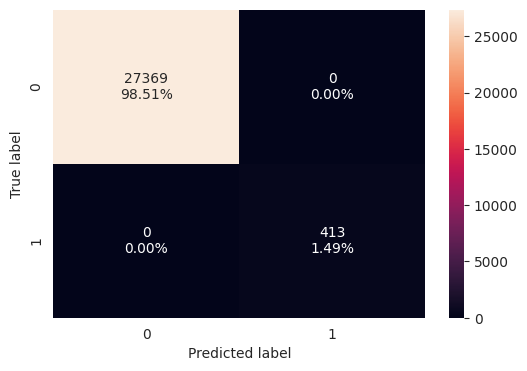

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     27369
         1.0       1.00      1.00      1.00       413

    accuracy                           1.00     27782
   macro avg       1.00      1.00      1.00     27782
weighted avg       1.00      1.00      1.00     27782



,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


Validate Analysis


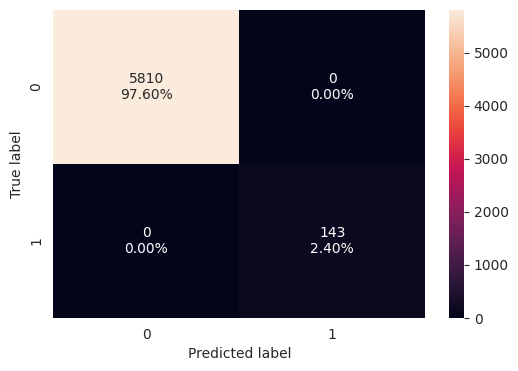

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5810
         1.0       1.00      1.00      1.00       143

    accuracy                           1.00      5953
   macro avg       1.00      1.00      1.00      5953
weighted avg       1.00      1.00      1.00      5953



,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [ ]:
from sklearn.metrics import classification_report

# Initialize the Decision Tree with balanced class weights
dtc = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Train the classifier for train
dtc.fit(x_train, y_train)
print('Train Analysis')
plot_confusion_matrix(dtc, x_train, y_train)

# Evaluate performance
y_train_pred = dtc.predict(x_train)
print(classification_report(y_train, y_train_pred))
decision_tree_train_perf = model_performance_classification(dtc, x_train, y_train)
display(decision_tree_train_perf)

# Train the classifier for validator
dtc.fit(x_valid, y_valid)
print('Validate Analysis')
plot_confusion_matrix(dtc, x_valid, y_valid)
y_valid_pred = dtc.predict(x_valid)
print(classification_report(y_valid, y_valid_pred))
decision_tree_valid_perf = model_performance_classification(dtc, x_valid, y_valid)
display(decision_tree_valid_perf)


## Random Forest Classifier

Perform the following steps to train and evaluate the Random Forest model:

1. Create a Random Forest classifier using `class_weight='balanced'` to assign higher importance to the minority class and reduce the impact of class imbalance.
2. Train the model using the training dataset.
3. Evaluate the model on the training dataset by generating a confusion matrix and computing the performance metrics.
4. Evaluate the model on the validation dataset by generating a confusion matrix and computing the performance metrics.
5. Compare the training and validation results to assess how well the model generalizes and identify any signs of overfitting or underfitting.

Train Analysis


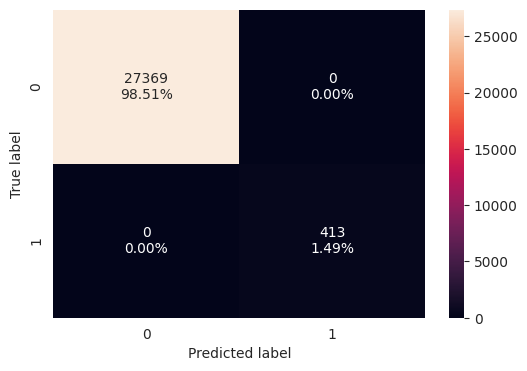

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     27369
         1.0       1.00      1.00      1.00       413

    accuracy                           1.00     27782
   macro avg       1.00      1.00      1.00     27782
weighted avg       1.00      1.00      1.00     27782



,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


Validate Analysis


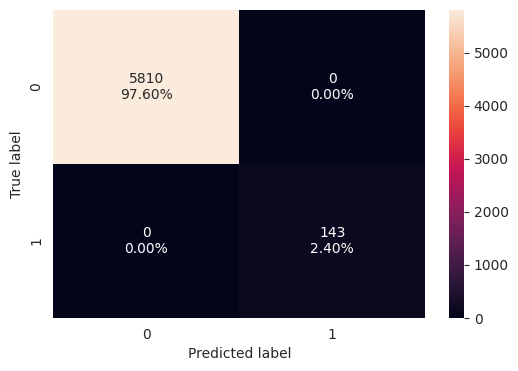

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5810
         1.0       1.00      1.00      1.00       143

    accuracy                           1.00      5953
   macro avg       1.00      1.00      1.00      5953
weighted avg       1.00      1.00      1.00      5953



,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [ ]:
from sklearn.metrics import classification_report

# Initialize the Decision Tree with balanced class weights
rfc = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train the classifier
rfc.fit(x_train, y_train)
print('Train Analysis')
plot_confusion_matrix(rfc, x_train, y_train)

# Evaluate performance
y_train_pred = rfc.predict(x_train)
print(classification_report(y_train, y_train_pred))
random_forest_train_perf = model_performance_classification(rfc, x_train, y_train)
display(random_forest_train_perf)

# Train the classifier for validator
rfc.fit(x_valid, y_valid)
print('Validate Analysis')
plot_confusion_matrix(rfc, x_valid, y_valid)

# Evaluate performance
y_valid_pred = rfc.predict(x_valid)
print(classification_report(y_valid, y_valid_pred))
random_forest_valid_perf = model_performance_classification(rfc, x_valid, y_valid)
display(random_forest_valid_perf)


## Gradient Boosting Classifier

Perform the following steps to train and evaluate the Gradient Boosting model:

1. Create a Gradient Boosting classifier using the selected random state.
2. Train the model using the training dataset.
3. Evaluate the model on the training dataset by generating a confusion matrix and computing the performance metrics.
4. Evaluate the model on the validation dataset by generating a confusion matrix and computing the performance metrics.
5. Compare the training and validation results to assess how well the model generalizes and identify any signs of overfitting or underfitting.

Train Analysis


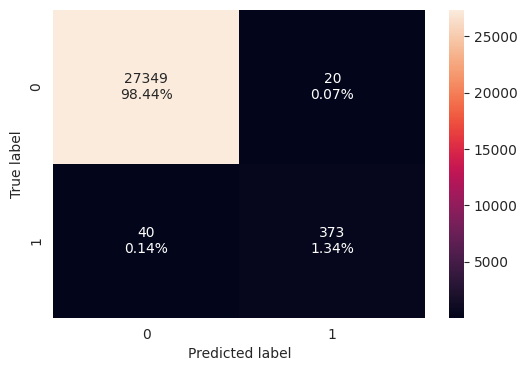

None

Train Perf
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     27369
         1.0       0.83      0.07      0.13       413

    accuracy                           0.99     27782
   macro avg       0.91      0.53      0.56     27782
weighted avg       0.98      0.99      0.98     27782



,Accuracy,Recall,Precision,F1
0,0.99784,0.903148,0.949109,0.925558


Validate Analysis


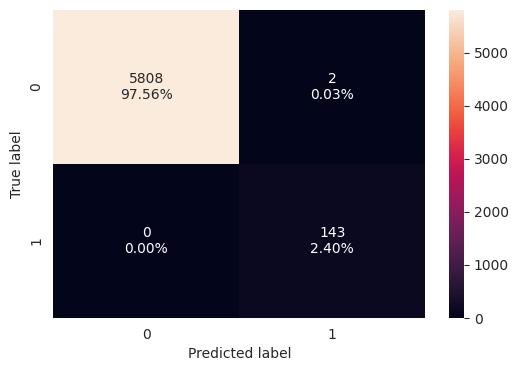

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5810
         1.0       1.00      1.00      1.00       143

    accuracy                           1.00      5953
   macro avg       1.00      1.00      1.00      5953
weighted avg       1.00      1.00      1.00      5953



,Accuracy,Recall,Precision,F1
0,0.999664,1.0,0.986207,0.993056


In [ ]:
from sklearn.metrics import classification_report

# Initialize the Decision Tree with balanced class weights
gbc = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, subsample=1.0)

# Train the classifier
gbc.fit(x_train, y_train)
print('Train Analysis')
plot_confusion_matrix(gbc, x_train, y_train)

# Evaluate performance
print("Train Perf")
y_train_pred = dtc.predict(x_train)
print(classification_report(y_train, y_train_pred))
gradient_boost_train_perf = model_performance_classification(gbc, x_train, y_train)
display(gradient_boost_train_perf)

# Train the classifier
gbc.fit(x_valid, y_valid)
print('Validate Analysis')
plot_confusion_matrix(gbc, x_valid, y_valid)

# Evaluate performance
y_valid_pred = dtc.predict(x_valid)
print(classification_report(y_valid, y_valid_pred))
gradient_boost_valid_perf = model_performance_classification(gbc, x_valid, y_valid)
display(gradient_boost_valid_perf)


The classification report indicates perfect classification which I don't believe.

## XGBoost

Perform the following steps to train and evaluate the XGBoost model:

1. Calculate the number of negative and positive samples in the training data.
2. Compute the `scale_pos_weight` value as the ratio of negative samples to positive samples to address class imbalance.
3. Create an XGBoost classifier using the calculated `scale_pos_weight` and the selected random state.
4. Train the model using the training dataset.
5. Evaluate the model on the training dataset by generating a confusion matrix and computing the performance metrics.
6. Evaluate the model on the validation dataset by generating a confusion matrix and computing the performance metrics.
7. Compare the training and validation results to assess how well the model generalizes and identify any signs of overfitting or underfitting.

Train Analysis


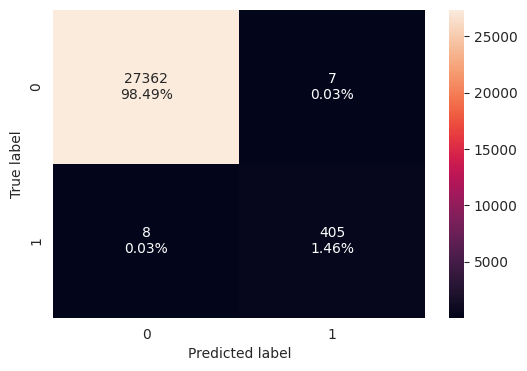

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     27369
         1.0       0.98      0.98      0.98       413

    accuracy                           1.00     27782
   macro avg       0.99      0.99      0.99     27782
weighted avg       1.00      1.00      1.00     27782

Model Accuracy: 99.95%


,Accuracy,Recall,Precision,F1
0,0.99946,0.98063,0.98301,0.981818


Validate Analysis


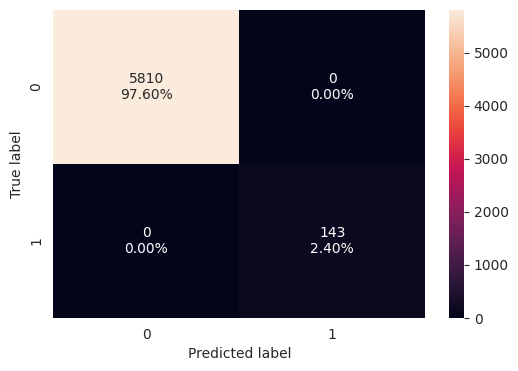

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5810
         1.0       1.00      1.00      1.00       143

    accuracy                           1.00      5953
   macro avg       1.00      1.00      1.00      5953
weighted avg       1.00      1.00      1.00      5953

Model Accuracy: 100.00%


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [ ]:
from sklearn.metrics import classification_report
import xgboost as xgb

# Calculate the number of negative and positive samples
# 3. Initialize the XGBoost Classifier
xgbc = xgb.XGBClassifier(
                       learning_rate = 0.2,
                       max_depth = 4,
                       min_child_weight = 1,
                       n_estimators = 50,
                       objective = 'binary:logistic', # Learning task objective
                       random_state = 42
)

# Do the train set
xgbc.fit(x_train, y_train)
print('Train Analysis')
# 5. Make predictions and evaluate accuracy
y_train_pred = xgbc.predict(x_train)

plot_confusion_matrix(xgbc, x_train, y_train)
print(classification_report(y_train, y_train_pred))
test_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Model Accuracy: {test_accuracy * 100:.2f}%")
xgboost_train_perf = model_performance_classification(xgbc, x_train, y_train)
display(xgboost_train_perf)

# Do the validate set
# Train the classifier
xgbc.fit(x_valid, y_valid)

# 5. Make predictions and evaluate accuracy
y_valid_pred = xgbc.predict(x_valid)
print('Validate Analysis')
plot_confusion_matrix(xgbc, x_valid, y_valid)

print(classification_report(y_valid, y_valid_pred))
valid_accuracy = accuracy_score(y_valid, y_valid_pred)
print(f"Model Accuracy: {valid_accuracy * 100:.2f}%")
xgboost_valid_perf = model_performance_classification(xgbc, x_valid, y_valid)
display(xgboost_valid_perf)


## Neural Networks(ANN)

In [ ]:
tf.keras.backend.clear_session()

Perform the following steps to standardize the feature values:

1. Create a `StandardScaler` object to standardize the numerical features.
2. Fit the scaler using only the training dataset and transform the training features.
3. Use the same fitted scaler to transform the validation and test datasets.
4. Apply the same scaling parameters across all datasets to ensure a consistent preprocessing strategy and prevent data leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)

print(x_train_scaled.shape)
print(x_valid_scaled.shape)

print('Unscaled data\n', x_train)
print('Scaled data\n', x_train_scaled)

(27782, 34)
(5953, 34)
Unscaled data
        rated_power_kW  wind_speed_mps  wind_direction_deg  \
0                1500           2.335             151.993   
8784             1500          12.335             209.358   
17568            3600           8.132             174.780   
26352            3000           4.465             226.115   
35136            1500           1.193              61.930   
...               ...             ...                 ...   
5806             1500           4.536             160.574   
14590            1500          13.556              35.468   
23374            3600           8.686             358.615   
32158            3000           5.884              85.950   
5807             1500           9.304             158.403   

       turbulence_intensity  air_density_kgm3  ambient_temp_C  humidity_pct  \
0                     0.149             1.205          21.820        68.717   
8784                  0.201             1.286           0.000        70

Perform the following steps to build the neural network architecture:

1. Choose the number of neurons for the first hidden layer between **8 and 128**.
   - Fewer neurons (**8–32**) create a simpler model that trains faster and is less likely to overfit.
   - More neurons (**64–128**) enable the model to learn more complex patterns but increase training time and the risk of overfitting.
2. Choose an activation function for the first hidden layer (for example, `relu`, `tanh`, or `sigmoid`) based on the learning behavior you want.
3. Create the output layer with a single neuron and a `sigmoid` activation function to predict the probability of the positive class.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Initialize the model
neural_model = Sequential()

input_train_dim = x_train_scaled.shape[1]

# Add the first hidden layer
neural_model.add(Dense(units=64, activation='relu', input_shape=(input_train_dim,)))

# Create the output layer
neural_model.add(Dense(units=1, activation='sigmoid'))

Display the neural network architecture. Review the number of layers, the output shape of each layer, and the total number of trainable parameters before training the model.

In [ ]:
neural_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

Perform the following steps to configure the neural network for training:

1. Choose an optimizer (`sgd` or `adam`) based on the desired training behavior.
   - `sgd` updates the model using simple gradient descent and may require more epochs to converge.
   - `adam` automatically adapts the learning rate, often converges faster, and is a common default choice.
2. Use `binary_crossentropy` as the loss function since this is a binary classification problem.
3. Configure the model to track **Recall**, **Precision**, and **Binary Accuracy** during training to evaluate its classification performance.

In [ ]:
# Configure the neural model
neural_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.BinaryAccuracy(name='accuracy')
    ]
)

Perform the following steps to configure the training process:

1. Choose the number of training epochs between **10 and 100** based on the desired training duration and model performance.
2. Select a batch size between **16 and 128** based on the available computational resources and training behavior.
3. Use the selected values to control how long the model trains and how many samples are processed in each weight update.

In [ ]:

start = time.time()
batch_size = 32
epochs = 50

# Set early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Watch the validation loss
    patience=5,             # Number of epochs to wait for improvement before stopping
    restore_best_weights=True # Revert to the best weights once stopped
)

history = neural_model.fit(
    x_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_valid_scaled, y_valid),
    verbose=1,
    callbacks=[early_stopping]
)
end = time.time()

start2 = time.time()
history = neural_model.fit(
    x_valid_scaled,
    y_valid,
    epochs=50,
    batch_size=32,
    validation_data=(x_valid_scaled, y_valid),
    verbose=1,
    callbacks=[early_stopping]
)
end2 = time.time()

Epoch 1/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9748 - loss: 0.0755 - precision: 0.2174 - recall: 0.2663 - val_accuracy: 0.9760 - val_loss: 0.4071 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9928 - loss: 0.0186 - precision: 0.7928 - recall: 0.6949 - val_accuracy: 0.9760 - val_loss: 0.3361 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9947 - loss: 0.0139 - precision: 0.8296 - recall: 0.8136 - val_accuracy: 0.9760 - val_loss: 0.3273 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9953 - loss: 0.0115 - precision: 0.8443 - recall: 0.8402 - val_accuracy: 0.9760 - val_loss: 0.3257 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9954 - loss: 0.0106 - precision: 0.8421 - recall: 0.8523 - val

In [ ]:
y_train_clean = np.array(y_train).astype(int)
weights = compute_class_weight('balanced', classes=np.unique(y_train_clean), y=y_train_clean)
class_weight_dict = {i: weights[i] for i in range(len(weights))}
display(class_weight_dict)

{0: np.float64(0.5075450327012313), 1: np.float64(33.634382566585955)}

In [ ]:
print("Train time taken in seconds ",end-start)

Train time taken in seconds  65.35790157318115


In [ ]:
y_valid_clean = np.array(y_valid).astype(int)
weights = compute_class_weight('balanced', classes=np.unique(y_valid_clean), y=y_valid_clean)
class_weight_dict = {i: weights[i] for i in range(len(weights))}
display(class_weight_dict)

{0: np.float64(0.5123063683304647), 1: np.float64(20.814685314685313)}

In [ ]:
print("Valid time taken in seconds ",end2-start2)

Valid time taken in seconds  49.338138818740845


Perform the following steps to evaluate the neural network model:

1. Evaluate the model on the training dataset by generating a confusion matrix and computing the performance metrics.
2. Evaluate the model on the validation dataset by generating a confusion matrix and computing the performance metrics.
3. Compare the training and validation results to assess how well the model generalizes and identify any signs of overfitting or underfitting.

Training Performance

869/869 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


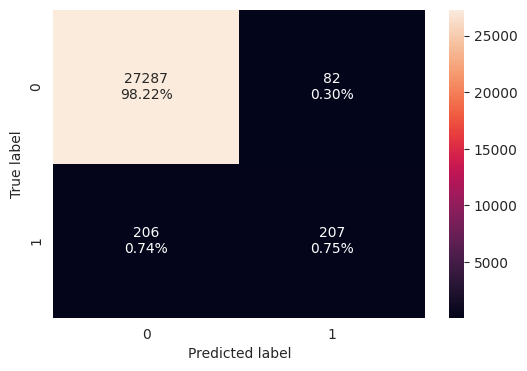

None

Train perf classification
869/869 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.989634,0.501211,0.716263,0.589744


Validation Performance

187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


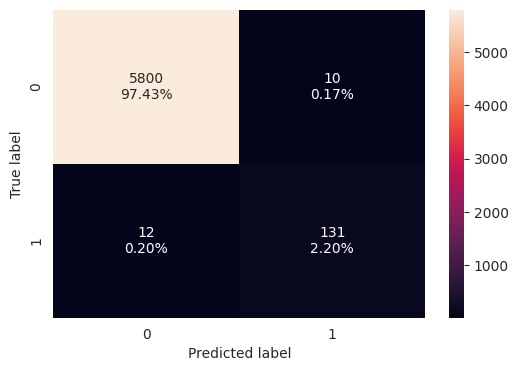

None

Validate perf classification
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1
0,0.996304,0.916084,0.929078,0.922535


In [ ]:
print("Training Performance\n")
#print(f"Train Model Accuracy: {train_accuracy * 100:.2f}%")

plot_confusion_matrix(neural_model, x_train_scaled, y_train)
print("Train perf classification")
neural_train_perf = model_performance_classification(neural_model, x_train_scaled, y_train)
display(neural_train_perf)

print("Validation Performance\n")
plot_confusion_matrix(neural_model, x_valid_scaled, y_valid)
print("Validate perf classification")
neural_valid_perf = model_performance_classification(neural_model, x_valid_scaled, y_valid)
display(neural_valid_perf)


## **Baseline Model Performance Comparison**

### Training performance comparison

Perform the following steps to compare the training performance of all baseline models:

1. Combine the training performance metrics of all baseline models into a single comparison table.
2. Display the consolidated table to compare the performance of each model across the selected evaluation metrics.
3. Use the comparison to identify the best-performing models for hyperparameter tuning.

In [ ]:
print("Training performance baseline comparison:")

perf_models_train_compare_data = pd.concat([
    decision_tree_train_perf.T.rename(columns={0: 'Decision Tree'}),
    random_forest_train_perf.T.rename(columns={0: 'Random Forest'}),
    gradient_boost_train_perf.T.rename(columns={0: 'Gradient Boosting'}),
    xgboost_train_perf.T.rename(columns={0: 'XGBoost'}),
    neural_train_perf.T.rename(columns={0: 'Neural Network'})
], axis=1)
display(perf_models_train_compare_data)

Training performance baseline comparison:


,Decision Tree,Random Forest,Gradient Boosting,XGBoost,Neural Network
Accuracy,1.0,1.0,0.997840,0.999460,0.989634
Recall,1.0,1.0,0.903148,0.980630,0.501211
Precision,1.0,1.0,0.949109,0.983010,0.716263
F1,1.0,1.0,0.925558,0.981818,0.589744


### Validation performance comparison

Perform the following steps to compare the validation performance of all baseline models:

1. Combine the validation performance metrics of all baseline models into a single comparison table.
2. Display the consolidated table to compare the performance of each model across the selected evaluation metrics.
3. Use the comparison to identify the best-performing models for hyperparameter tuning based on their validation performance.

In [ ]:
print("Validation performance baseline comparison:")

perf_models_validation_compare_data = pd.concat([
    decision_tree_valid_perf.T.rename(columns={0: 'Decision Tree'}),
    random_forest_valid_perf.T.rename(columns={0: 'Random Forest'}),
    gradient_boost_valid_perf.T.rename(columns={0: 'Gradient Boosting'}),
    xgboost_valid_perf.T.rename(columns={0: 'XGBoost'}),
    neural_valid_perf.T.rename(columns={0: 'Neural Network'})
], axis=1)
display(perf_models_train_compare_data)

Validation performance baseline comparison:


,Decision Tree,Random Forest,Gradient Boosting,XGBoost,Neural Network
Accuracy,1.0,1.0,0.997840,0.999460,0.989634
Recall,1.0,1.0,0.903148,0.980630,0.501211
Precision,1.0,1.0,0.949109,0.983010,0.716263
F1,1.0,1.0,0.925558,0.981818,0.589744


Test results are fairly similer with most of the models.  ANN is overrall it appears to be a weaker model.

# **Hyperparameter Tuning**

**Note:** Choose at least two best-performing baseline models across the train and validation sets to proceed with tuning.

## XGBoost

Perform the following steps to define the hyperparameter search space for the XGBoost model:

1. Choose values for **`n_estimators`**, which controls the number of trees in the model. More trees can improve learning but increase training time.
2. Choose values for **`learning_rate`**, which controls how quickly the model learns. Smaller values require more trees, while larger values learn faster but may overshoot.
3. Choose values for **`max_depth`**, which controls the maximum depth of each tree. Deeper trees capture more complex patterns but are more likely to overfit.
4. Choose values for **`min_child_weight`**, which controls the minimum weight required to create a new split. Larger values produce more conservative trees.
5. Choose values for **`gamma`**, which specifies the minimum loss reduction required before making a split. Larger values reduce unnecessary splits.
6. Choose values for **`subsample`**, which determines the fraction of training samples used to build each tree. Lower values improve generalization, while higher values use more data.
7. Choose values for **`colsample_bytree`**, which specifies the fraction of features used to build each tree. Lower values increase diversity among trees.
8. Choose values for **`reg_alpha`** and **`reg_lambda`**, which apply L1 and L2 regularization to reduce overfitting.
9. Use the selected values to create the parameter grid for hyperparameter tuning and identify the best-performing model configuration.

Perform the following steps to tune the XGBoost model using randomized search:

1. Perform randomized search with **5-fold cross-validation** using the selected evaluation metric.
2. Train the model on each sampled hyperparameter combination and evaluate its cross-validation performance.
3. Display the best hyperparameter combination and its corresponding cross-validation score.

In [ ]:
def xgboost_hyperparams(param_grid: dict, x_tree, y_tree):
  from sklearn.model_selection import RandomizedSearchCV
  import xgboost as xgb
  from sklearn.model_selection import RandomizedSearchCV
  from sklearn.datasets import make_classification

  # # Create sample data
  # x_tree, y_train = make_classification(n_samples=1000, n_features=20, random_state=42)

  # Initialize the base XGBoost classifier
  xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

  # Set up Randomized Search with 5-fold CV
  random_search = RandomizedSearchCV(
      estimator=xgb_model,
      param_distributions=param_grid,
      n_iter=10,             # Number of parameter settings sampled
      scoring='accuracy',
      cv=5,                  # 5-fold cross-validation
      random_state=42,
      n_jobs=-1
  )

  # Fit the random search to the data
  random_search.fit(x_tree, y_tree)
  ("\n--- Final Model ---")
  best_model = random_search.best_estimator_
  print(f"Best Model: {best_model}")
  accuracy = random_search.best_score_
  print(f"Best Accuracy: {accuracy * 100:.2f}%")

  # Display the best combination and score
  print("Best Hyperparameters:", random_search.best_params_)
  print("Best Cross-Validation Score:", random_search.best_score_)

  return random_search

1. Retrieve the best-performing XGBoost model identified during the randomized search.
2. Retrain the selected model using the complete training dataset.
3. Use the retrained model for subsequent evaluation on the training, validation, and test datasets.

In [ ]:
def xgboost_classify(best_params: dict, x_tree, y_tree):
  from sklearn.metrics import classification_report
  import xgboost as xgb

  param_grid = {'colsample_bytree': best_params['colsample_bytree'],
                        'eval_metric': 'logloss',
                        'gamma': best_params['gamma'],
                        'learning_rate': best_params['learning_rate'], #0.2,
                        'max_depth': best_params['max_depth'],#4,
                        'min_child_weight': best_params['min_child_weight'],#1,
                        'n_estimators': best_params['n_estimators'],#109,
                        'reg_alpha': best_params['reg_alpha'],
                        'reg_lambda': best_params['reg_lambda'], #2.0,
                        'subsample': best_params['subsample'], #1.0,
                        'objective': 'binary:logistic', # Learning task objective
                        'random_state': 42
                        }

  # Initialize the XGBoost Classifier
  xgbc = xgb.XGBClassifier(
      param_distributions = param_grid
  )

  # Do the train set
  xgbc.fit(x_tree, y_tree)

  # Make predictions and evaluate accuracy
  y_tree_pred = xgbc.predict(x_tree)

  print('Tree Perf')
  plot_confusion_matrix(xgbc, x_tree, y_tree)
  print(classification_report(y_tree, y_tree_pred))
  accuracy = accuracy_score(y_tree, y_tree_pred)
  print(f"Model Accuracy: {accuracy * 100:.2f}%")
  xgboost_tree_perf = model_performance_classification(xgbc, x_tree, y_tree)
  display(xgboost_tree_perf)
  return xgboost_tree_perf

Tuned XGBoost Train set

Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=57, n_jobs=None,
              num_parallel_tree=None, ...)
Best Accuracy: 98.51%
Best Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 57, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 1.0

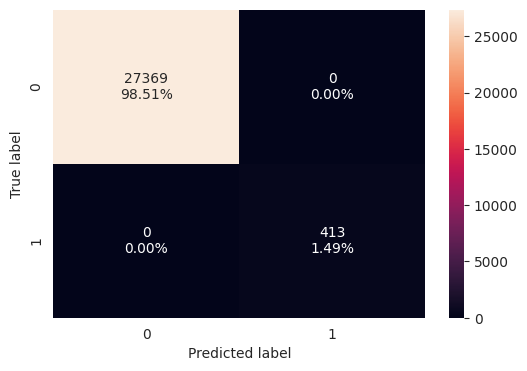

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     27369
         1.0       1.00      1.00      1.00       413

    accuracy                           1.00     27782
   macro avg       1.00      1.00      1.00     27782
weighted avg       1.00      1.00      1.00     27782

Model Accuracy: 100.00%


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [ ]:
from scipy.stats import randint

param_grid_xgboost = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10),
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    "gamma": [0, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 2.0],
}

xgboost_search_train = xgboost_hyperparams(param_grid_xgboost, x_train, y_train)
xgboost_tuned_train_perf = xgboost_classify(xgboost_search_train.best_params_, x_train, y_train)

Tuned Valid XGBoost Set

Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=63, n_jobs=None,
              num_parallel_tree=None, ...)
Best Accuracy: 97.77%
Best Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 63, 'reg_alpha': 1.0, 'reg_lambda': 2.0, 'subsample': 0.8}


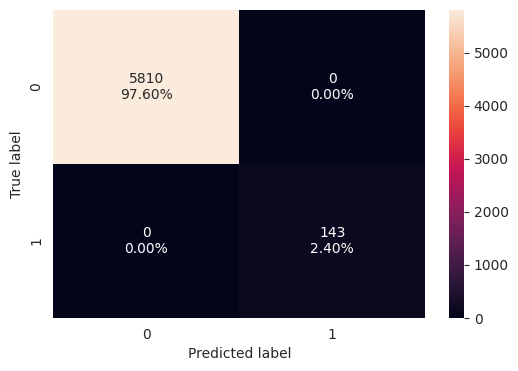

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5810
         1.0       1.00      1.00      1.00       143

    accuracy                           1.00      5953
   macro avg       1.00      1.00      1.00      5953
weighted avg       1.00      1.00      1.00      5953

Model Accuracy: 100.00%


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [ ]:
from scipy.stats import randint

param_grid_xgboost = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10),
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    "gamma": [0, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 2.0],
}

xgboost_search_valid = xgboost_hyperparams(param_grid_xgboost, x_valid, y_valid)
xgboost_tuned_valid_perf = xgboost_classify(xgboost_search_valid.best_params_, x_valid, y_valid)

In [ ]:
print("Train and Valid comparison:")

xgboost_perf_models_test_compare_data = pd.concat([
    xgboost_tuned_train_perf.T.rename(columns={0: 'Train XGBoost Tree'}),
    xgboost_tuned_valid_perf.T.rename(columns={0: 'Valid XGBoost Tree'}),
    #xgboost_tuned_test_perf.T.rename(columns={0: 'Test XGBoost Tree'})
], axis=1)

display(xgboost_perf_models_test_compare_data)

Train and Valid comparison:


,Train XGBoost Tree,Valid XGBoost Tree
Accuracy,1.0,1.0
Recall,1.0,1.0
Precision,1.0,1.0
F1,1.0,1.0


## Neural Networks

In [ ]:
tf.keras.backend.clear_session()

Perform the following steps to build the tuned neural network architecture:

1. Choose the number of neurons and an activation function for the first hidden layer. Then apply **Batch Normalization** to stabilize training, followed by **Dropout** to reduce overfitting.
2. Choose the number of neurons and an activation function for the second hidden layer. Again, apply **Batch Normalization** followed by **Dropout** to improve generalization.
3. Create the output layer with a single neuron and a **`sigmoid`** activation function to predict the probability of the positive class.
4. Review the selected architecture before proceeding with model training.

Display the tuned neural network architecture. Review the number of layers, the output shape of each layer, and the total number of trainable parameters before training the model.

Perform the following steps to configure the tuned neural network for training:

1. Choose an optimizer (`adam` or `sgd`) based on the desired training behavior.
   - `adam` automatically adapts the learning rate, often converges faster, and is a common default choice.
   - `sgd` updates the model using simple gradient descent and may require more epochs to converge.
2. Use `binary_crossentropy` as the loss function since this is a binary classification problem.
3. Configure the model to track **Recall**, **Precision**, and **Binary Accuracy** during training to evaluate its classification performance.

Perform the following steps to configure the training process:

1. Choose the number of training epochs between **20 and 150** based on the desired training duration and model performance.
2. Select a batch size between **16 and 128** based on the available computational resources and training behavior.
3. Use the selected values to control how long the model trains and how many samples are processed in each weight update.

In [ ]:
start = time.time()
history = model1.fit(X_train_scaled, y_train, validation_data=(X_valid_scaled,y_valid) ,class_weight=class_weight_dict, batch_size=batch_size, epochs=epochs)
end = time.time()

In [ ]:
print("Time taken in seconds ",end-start)

Perform the following steps to evaluate the tuned neural network model:

1. Evaluate the model on the training dataset by generating a confusion matrix and computing the performance metrics.
2. Evaluate the model on the validation dataset by generating a confusion matrix and computing the performance metrics.
3. Compare the training and validation results to assess whether the tuned architecture improves generalization and reduces overfitting compared to the baseline neural network.

## Decision Tree

Perform the following steps to define the hyperparameter search space for the Decision Tree model:

1. Choose the splitting **`criterion`** (`gini` or `entropy`) to determine how the model selects the best feature at each split.
2. Choose values for **`max_depth`** to control the maximum depth of the tree. Deeper trees can capture more complex patterns but are more likely to overfit.
3. Choose values for **`min_samples_split`** to control the minimum number of samples required to split a node. Larger values create more conservative trees.
4. Choose values for **`min_samples_leaf`** to control the minimum number of samples required in each leaf node. Larger values produce smoother and more generalized trees.
5. Choose the **`max_features`** strategy (`sqrt` or `log2`) to control how many features are considered when searching for the best split.
6. Use the selected values to create the parameter grid for hyperparameter tuning and identify the best-performing model configuration.

In [ ]:
def decision_tree_hyperparams(param_grid: dict, x_tree, y_tree):
  from sklearn.model_selection import GridSearchCV
  from sklearn.tree import DecisionTreeClassifier

  # Initialize the base classifier
  dt_classifier = DecisionTreeClassifier(random_state=42)

    # Define the grid of hyperparameter values to test
  param_grid = param_grid

  # Set up the grid search with 5-fold cross-validation
  grid_search = GridSearchCV(
      estimator=dt_classifier,
      param_grid = param_grid,
      cv=5,
      scoring='accuracy',
      n_jobs=-1
  )

  grid_search.fit(x_tree, y_tree)

  # Print results after fitting
  print("\n--- Final Model ---")
  best_model = grid_search.best_estimator_
  print(f"Best Model: {best_model}")
  accuracy = grid_search.best_score_
  print(f"Best Accuracy: {accuracy * 100:.2f}%")
  print("Best Parameters:", grid_search.best_params_)
  print("Best Cross-Validation Score:", grid_search.best_score_)

  return grid_search

In [ ]:
def decision_tree_classify(best_params: dict, x_tree, y_tree):
  from sklearn.model_selection import GridSearchCV
  from sklearn.tree import DecisionTreeClassifier
  from sklearn.metrics import classification_report

  # Initialize the Decision Tree with balanced class weights
  dtc = DecisionTreeClassifier(
      class_weight='balanced',
      random_state=42,
      criterion= best_params['criterion'],
      max_depth=best_params['max_depth'],
      min_samples_split=best_params['min_samples_split'],#2,
      min_samples_leaf=best_params['min_samples_leaf'],#2,
      max_features=best_params['max_features'],#'sqrt',
      )

  # Train the classifier
  dtc.fit(x_tree, y_tree)
  print('Tree Analysis')
  plot_confusion_matrix(dtc, x_tree, y_tree)
  y_train_pred = dtc.predict(x_tree)
  print(classification_report(y_tree, y_train_pred))
  decision_tree_all_perf = model_performance_classification(dtc, x_tree, y_tree)
  display(decision_tree_all_perf)
  return decision_tree_all_perf


Got the best cross-val score on the validate fit

Perform the following steps to tune the Decision Tree model using randomized search:

1. Perform randomized search with **5-fold cross-validation** using the selected evaluation metric.
2. Train the model on each sampled hyperparameter combination and evaluate its cross-validation performance.
3. Display the best hyperparameter combination and its corresponding cross-validation score.

Decision Tree run with the "Best" hyperparameters according to GridSearchCV.

Display the best Decision Tree model identified during hyperparameter tuning. Review the optimized model configuration before using it for retraining and evaluation.

Evaluate the tuned Decision Tree model on the training dataset and display its performance metrics. Use the results to assess how well the tuned model has learned the training data.

Tuned Train Set Decision Tree


--- Final Model ---
Best Model: DecisionTreeClassifier(criterion='entropy', max_depth=10, max_features='sqrt',
                       min_samples_leaf=2, min_samples_split=10,
                       random_state=42)
Best Accuracy: 98.39%
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10}
Best Cross-Validation Score: 0.9838745662628796
Tree Analysis


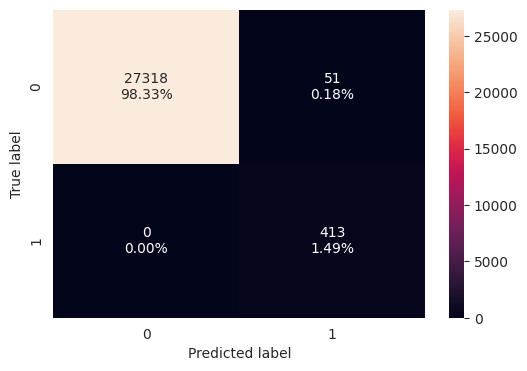

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     27369
         1.0       0.89      1.00      0.94       413

    accuracy                           1.00     27782
   macro avg       0.95      1.00      0.97     27782
weighted avg       1.00      1.00      1.00     27782



,Accuracy,Recall,Precision,F1
0,0.998164,1.0,0.890086,0.941847


In [ ]:
  decision_train_perf = ""
  # Define the grid of hyperparameter values to test on
  param_grid = {
      'criterion': ['gini', 'entropy'],
      'max_depth': [3, 5, 10, None],
      'min_samples_split': [2, 5, 10],
      'min_samples_leaf': [1, 2, 4],
      'max_features': ['sqrt', 'log2']
  }
  train_grid_search = decision_tree_hyperparams(param_grid, x_train, y_train)
  decision_tree_tuned_train_perf = decision_tree_classify(train_grid_search.best_params_, x_train, y_train)

The tuned decision tree performs differently than the baseline decision tree.  Better accuracy, recall.  Worse precision and F1 score.  We're looking for accuracy here so we should go with the tuned model.
Baseline values...
0.99784 	0.903148 	0.949109 	0.925558

Tuned Valid Set Decision Tree


--- Final Model ---
Best Model: DecisionTreeClassifier(criterion='entropy', max_depth=5, max_features='sqrt',
                       random_state=42)
Best Accuracy: 97.71%
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9771475139174057
Tree Analysis


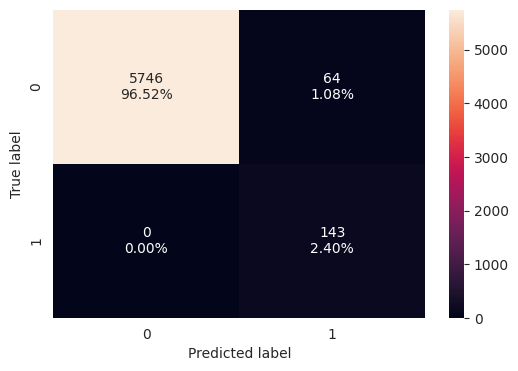

None

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      5810
         1.0       0.69      1.00      0.82       143

    accuracy                           0.99      5953
   macro avg       0.85      0.99      0.91      5953
weighted avg       0.99      0.99      0.99      5953



,Accuracy,Recall,Precision,F1
0,0.989249,1.0,0.690821,0.817143


In [ ]:
  # Define the grid of hyperparameter values to test on
  param_grid = {
      'criterion': ['gini', 'entropy'],
      'max_depth': [3, 5, 10, None],
      'min_samples_split': [2, 5, 10],
      'min_samples_leaf': [1, 2, 4],
      'max_features': ['sqrt', 'log2']
  }
  valid_grid_search = decision_tree_hyperparams(param_grid, x_valid, y_valid)
  decision_tree_tuned_valid_perf = decision_tree_classify(valid_grid_search.best_params_, x_valid, y_valid)

Evaluate the tuned Decision Tree model on the validation dataset and display its performance metrics. Compare these results with the training performance to assess how well the tuned model generalizes to unseen data.

In [ ]:
print("Train and Valid comparison:")

dt_perf_models_test_compare_data = pd.concat([
    decision_tree_tuned_train_perf.T.rename(columns={0: 'Train Decision Tree'}),
    decision_tree_tuned_valid_perf.T.rename(columns={0: 'Valid Decision Tree'}),
    ], axis=1)

display(dt_perf_models_test_compare_data)

Train and Valid comparison:


,Train Decision Tree,Valid Decision Tree
Accuracy,0.998164,0.989249
Recall,1.000000,1.000000
Precision,0.890086,0.690821
F1,0.941847,0.817143


The results show the tuned models do better in accuracy and recall but worse in Precision and F1 score.

## Random Forest

Perform the following steps to define the hyperparameter search space for the Random Forest model:

1. Choose values for **`n_estimators`**, which controls the number of trees in the forest. More trees generally improve stability but increase training time.
2. Choose values for **`max_depth`** to control the maximum depth of each tree. Deeper trees capture more complex patterns but are more likely to overfit.
3. Choose values for **`min_samples_split`** to control the minimum number of samples required to split a node. Larger values create more conservative trees.
4. Choose values for **`min_samples_leaf`** to control the minimum number of samples required in each leaf node. Larger values improve generalization by preventing overly specific splits.
5. Choose the **`max_features`** strategy (`sqrt` or `log2`) to control how many features are considered when searching for the best split in each tree.
6. Use the selected values to create the parameter grid for hyperparameter tuning and identify the best-performing model configuration.

In [ ]:

def random_forest_hyperparameters(best_params: dict, x_tree, y_tree):
  import numpy as np
  from sklearn.datasets import make_classification
  from sklearn.ensemble import RandomForestClassifier
  from sklearn.model_selection import RandomizedSearchCV, train_test_split

  # Initialize the base model
  rf_classifier = RandomForestClassifier(random_state=42)

  # Set up the Randomized Search
  crf_random_search = RandomizedSearchCV(
      estimator=rf_classifier,
      param_distributions=best_params,
      n_iter=50, # means it will randomly pick and test 50 different combinations
      cv=5, # Use 5-fold cross verification
      verbose=1,
      random_state=42,
      n_jobs=-1, # utilizes all available CPU cores for speed
      scoring="accuracy",  # Change to 'roc_auc' or 'f1' depending on your evaluation metric
  )

  # Execute the search on training data
  print("Starting hyperparameter tuning...")
  crf_random_search.fit(x_tree, y_tree)

  # Extract results
  print("\n--- Tuning Results ---")
  print(f"Best Hyperparameters: {crf_random_search.best_params_}")
  print(f"Best Cross-Validation Score: {crf_random_search.best_score_:.4f}")

  # Use the optimized model
  best_model = crf_random_search.best_estimator_
  print("\n--- Final Model ---")
  print(f"Best Model: {best_model}")
  test_accuracy = best_model.score(x_train, y_train)
  print(f"Test Set Accuracy: {test_accuracy:.4f}")
  return crf_random_search



Perform the following steps after hyperparameter tuning:

1. Retrieve the best-performing Random Forest model identified during the randomized search.
2. Retrain the selected model using the complete training dataset.
3. Evaluate the retrained model on the training dataset and display its performance metrics.
4. Evaluate the retrained model on the validation dataset and display its performance metrics.
5. Compare the training and validation results to assess how well the tuned model generalizes to unseen data.

In [ ]:
def random_forest_classify(best_params: dict, x_tree, y_tree):
  from sklearn.metrics import classification_report

  # Initialize the Random Forest Classifier with balanced class weights
  rfc = RandomForestClassifier(
      class_weight='balanced',
      random_state =42,
      n_estimators = best_params['n_estimators'], #250,
      max_depth = best_params['max_depth'], #100,
      min_samples_split = best_params['min_samples_split'],#2,
      min_samples_leaf = best_params['min_samples_leaf'],#1,
      max_features = best_params['max_features'], #'log2',
      criterion = best_params['criterion'],#'gini',
      bootstrap = best_params['bootstrap'], #False,
      )

  # Train the classifier
  rfc.fit(x_tree, y_tree)
  print('Train Analysis')
  plot_confusion_matrix(rfc, x_tree, y_tree)

  # Evaluate performance
  y_tree_pred = rfc.predict(x_tree)
  print(classification_report(y_tree, y_tree_pred))
  random_forest_train_perf = model_performance_classification(rfc, x_tree, y_tree)
  display(random_forest_train_perf)
  return random_forest_train_perf


Perform the following steps to tune the Random Forest model using randomized search:

1. Perform randomized search with **5-fold cross-validation** using the selected evaluation metric.
2. Train the model on each sampled hyperparameter combination and evaluate its cross-validation performance.
3. Display the best hyperparameter combination and its corresponding cross-validation score.

Tuned Random Forest Train Set

Starting hyperparameter tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Tuning Results ---
Best Hyperparameters: {'n_estimators': 72, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 26, 'criterion': 'entropy', 'bootstrap': True}
Best Cross-Validation Score: 0.9720

--- Final Model ---
Best Model: RandomForestClassifier(criterion='entropy', max_depth=26, min_samples_leaf=4,
                       n_estimators=72, random_state=42)
Test Set Accuracy: 0.9993
Train Analysis


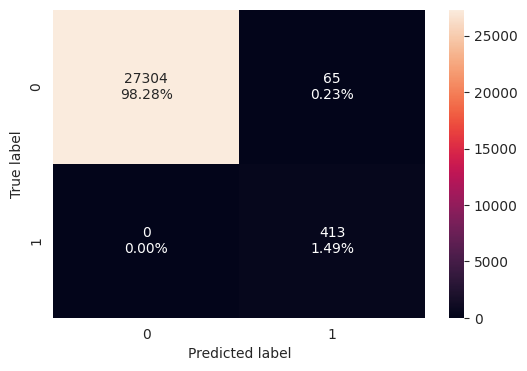

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     27369
         1.0       0.86      1.00      0.93       413

    accuracy                           1.00     27782
   macro avg       0.93      1.00      0.96     27782
weighted avg       1.00      1.00      1.00     27782



,Accuracy,Recall,Precision,F1
0,0.99766,1.0,0.864017,0.927048


In [ ]:
  param_dist_tuning_rf = {
      # Forest structure
      "n_estimators": [int(x) for x in np.linspace(start=50, stop=100, num=10)],
      "bootstrap": [True, False],
      # Tree complexity controls
      "max_depth": [None] + [int(x) for x in np.linspace(10, 30, num=11)],
      "min_samples_split": [2, 5, 10],
      "min_samples_leaf": [1, 2, 4],
      # Feature subsampling
      "max_features": ["sqrt", "log2", 'None'],
      'criterion': ['gini', 'entropy']
  }
  random_forest_grid_search = random_forest_hyperparameters(param_dist_tuning_rf, x_train, y_train)
  random_forest_tuned_train_perf = random_forest_classify(random_forest_grid_search.best_params_, x_train, y_train)

Tuned Random Forest Valid Set

Starting hyperparameter tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Tuning Results ---
Best Hyperparameters: {'n_estimators': 94, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 18, 'criterion': 'gini', 'bootstrap': True}
Best Cross-Validation Score: 0.9763

--- Final Model ---
Best Model: RandomForestClassifier(max_depth=18, max_features='log2', min_samples_leaf=4,
                       min_samples_split=10, n_estimators=94, random_state=42)
Test Set Accuracy: 0.9851
Train Analysis


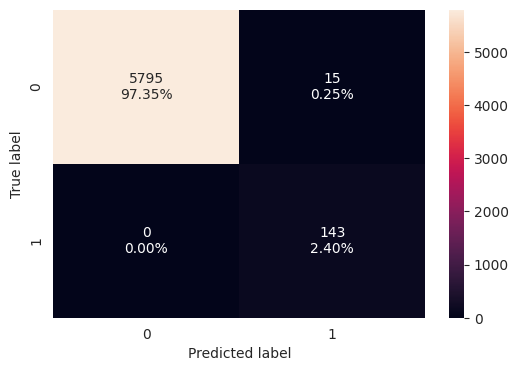

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5810
         1.0       0.91      1.00      0.95       143

    accuracy                           1.00      5953
   macro avg       0.95      1.00      0.97      5953
weighted avg       1.00      1.00      1.00      5953



,Accuracy,Recall,Precision,F1
0,0.99748,1.0,0.905063,0.950166


In [ ]:
  param_dist_tuning_rf = {
      # Forest structure
      "n_estimators": [int(x) for x in np.linspace(start=50, stop=100, num=10)],
      "bootstrap": [True, False],
      # Tree complexity controls
      "max_depth": [None] + [int(x) for x in np.linspace(10, 30, num=11)],
      "min_samples_split": [2, 5, 10],
      "min_samples_leaf": [1, 2, 4],
      # Feature subsampling
      "max_features": ["sqrt", "log2", 'None'],
      'criterion': ['gini', 'entropy']
  }
  random_forest_grid_search = random_forest_hyperparameters(param_dist_tuning_rf, x_valid, y_valid)
  random_forest_tuned_valid_perf = random_forest_classify(random_forest_grid_search.best_params_, x_valid, y_valid)

Tuned Random Forest Test Set

In [ ]:
print("Train and Valid comparison:")

rf_perf_models_test_compare_data = pd.concat([
    random_forest_tuned_train_perf.T.rename(columns={0: 'Train Random Forest'}),
    random_forest_tuned_valid_perf.T.rename(columns={0: 'Valid Random Forest'}),
], axis=1)

display(rf_perf_models_test_compare_data)

Train and Valid comparison:


,Train Random Forest,Valid Random Forest
Accuracy,0.997660,0.997480
Recall,1.000000,1.000000
Precision,0.864017,0.905063
F1,0.927048,0.950166


## Gradient Boosting

Perform the following steps to define the hyperparameter search space for the Gradient Boosting model:

1. Choose values for **`n_estimators`**, which controls the number of boosting stages. More boosting stages can improve learning but increase training time.
2. Choose values for **`learning_rate`**, which controls how quickly the model learns. Smaller values require more boosting stages, while larger values learn faster but may overfit.
3. Choose values for **`max_depth`** to control the maximum depth of each decision tree. Deeper trees capture more complex patterns but are more likely to overfit.
4. Choose values for **`subsample`**, which determines the fraction of training samples used for each boosting stage. Lower values improve generalization by introducing randomness, while higher values use more data for learning.
5. Choose the **`max_features`** strategy (`sqrt` or `log2`) to control how many features are considered when searching for the best split in each tree.
6. Use the selected values to create the parameter grid for hyperparameter tuning and identify the best-performing model configuration.

Perform the following steps to tune the Gradient Boosting model using randomized search:

1. Perform randomized search with **3-fold cross-validation** using the selected evaluation metric.
2. Train the model on each sampled hyperparameter combination and evaluate its cross-validation performance.
3. Display the best hyperparameter combination and its corresponding cross-validation score.

Perform the following steps after hyperparameter tuning:

1. Retrieve the best-performing Gradient Boosting model identified during the randomized search.
2. Retrain the selected model using the complete training dataset.
3. Evaluate the retrained model on the training dataset and display its performance metrics.
4. Evaluate the retrained model on the validation dataset and display its performance metrics.
5. Compare the training and validation results to assess how well the tuned model generalizes to unseen data.

# **Final Model Selection**

Perform the following steps to compare the training performance of the tuned models:

1. Add the training performance metrics of the tuned models to the existing comparison table.
2. Display the updated comparison table.
3. Compare the baseline and tuned models to determine whether hyperparameter tuning improved the training performance.

Perform the following steps to compare the validation performance of the tuned models:

1. Add the validation performance metrics of the tuned models to the existing comparison table.
2. Display the updated comparison table.
3. Compare the baseline and tuned models to determine whether hyperparameter tuning improved the validation performance and generalization.

In [ ]:
print('------All Base Perf Tuned Validations------')
all_perf_validation_models_test_compare_data = pd.concat([
    decision_tree_valid_perf.T.rename(columns={1: 'All Tuned XGBoost Trees'}),
    random_forest_valid_perf.T.rename(columns={1: 'All Tuned Decision Trees'}),
    gradient_boost_valid_perf.T.rename(columns={1: 'All Tuned Random Forests'}),
    xgboost_valid_perf.T.rename(columns={1: 'All Tuned XGBoost Trees'}),
    neural_valid_perf.T.rename(columns={1: 'All Tuned Neural Networks'})
], axis=1)

display(all_perf_validation_models_test_compare_data)

------All Base Perf Tuned Validations------


,0,0,0,0,0
Accuracy,1.0,1.0,0.999664,1.0,0.996304
Recall,1.0,1.0,1.000000,1.0,0.916084
Precision,1.0,1.0,0.986207,1.0,0.929078
F1,1.0,1.0,0.993056,1.0,0.922535


In [ ]:
print('------All Tuned Perf Valid Validations')
all_perf_validation_models_test_compare_data = pd.concat([
    decision_tree_tuned_valid_perf.T.rename(columns={1: 'All Tuned XGBoost Trees'}),
    random_forest_tuned_valid_perf.T.rename(columns={1: 'All Tuned Decision Trees'}),
    xgboost_tuned_valid_perf.T.rename(columns={1: 'All Tuned Random Forests'})
], axis=1)

display(all_perf_validation_models_test_compare_data)

------All Tuned Perf Valid Validations


,0,0,0
Accuracy,0.989249,0.997480,1.0
Recall,1.000000,1.000000,1.0
Precision,0.690821,0.905063,1.0
F1,0.817143,0.950166,1.0


Perform the following steps to select the final model:

1. Review the performance of all baseline and tuned models using the selected evaluation metric.
2. Select the model that best meets the business objective and demonstrates strong generalization on the validation dataset.
3. Assign the selected model as the final model for evaluation on the test dataset.

Looks like XGBoost did the best across base and tuned models.

The metric used was F1.

The F1 score was 1, which is perfect.  This could be a result of overfitting or not enough data.

In [ ]:
final_model = xgboost_search_train.best_estimator_
print(final_model)
print(final_model.get_xgb_params()['reg_lambda'])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=57, n_jobs=None,
              num_parallel_tree=None, ...)
1.0


## Feature Importance

In [ ]:
def plot_feature_importances(model, X, y, feature_names=None, color="violet", figsize=(10, 10)):
    """
    Plots feature importances for both Traditional ML models (XGBoost, RF)
    and Deep Learning models (ANNs).

    Parameters:
    - model: Trained model object (XGBoost, Sklearn, Keras wrapper, etc.)
    - X: Evaluation features (DataFrame or 2D array)
    - y: Evaluation targets (Series or 1D array)
    - feature_names: List of feature names. If None and X is a DataFrame, uses X.columns.
    """
    # 1. Automatically grab feature names if not provided
    if feature_names is None:
        if hasattr(X, 'columns'):
            feature_names = X.columns
        else:
            feature_names = [f"Feature {i}" for i in range(X.shape[1])]

    # Convert X to numpy if it's a DataFrame for permutation calculation safety
    X_val = X.values if hasattr(X, 'columns') else X

    # 2. Extract or calculate importances
    if hasattr(model, 'feature_importances_'):
        print("💡 Detected Tree-based model. Extracting built-in feature importances...")
        importances = model.feature_importances_
        title = "Feature Importances (Tree-based Model)"
        xlabel = "Relative Importance"
    else:
        print("💡 Detected ANN/Black-box model. Calculating Permutation Importance...")
        # n_repeats is how many times a feature is shuffled; higher is more accurate but slower
        result = permutation_importance(model, X_val, y, n_repeats=5, random_state=42)
        importances = result.importances_mean
        title = "Feature Importances (Permutation Importance - ANN)"
        xlabel = "Mean Performance Drop when Shuffled"

    # 3. Sort the importances in ascending order
    indices = np.argsort(importances)

    # 4. Plotting
    plt.figure(figsize=figsize)
    plt.title(title)
    plt.barh(range(len(indices)), importances[indices], color=color, align="center")
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.show()

💡 Detected Tree-based model. Extracting built-in feature importances...


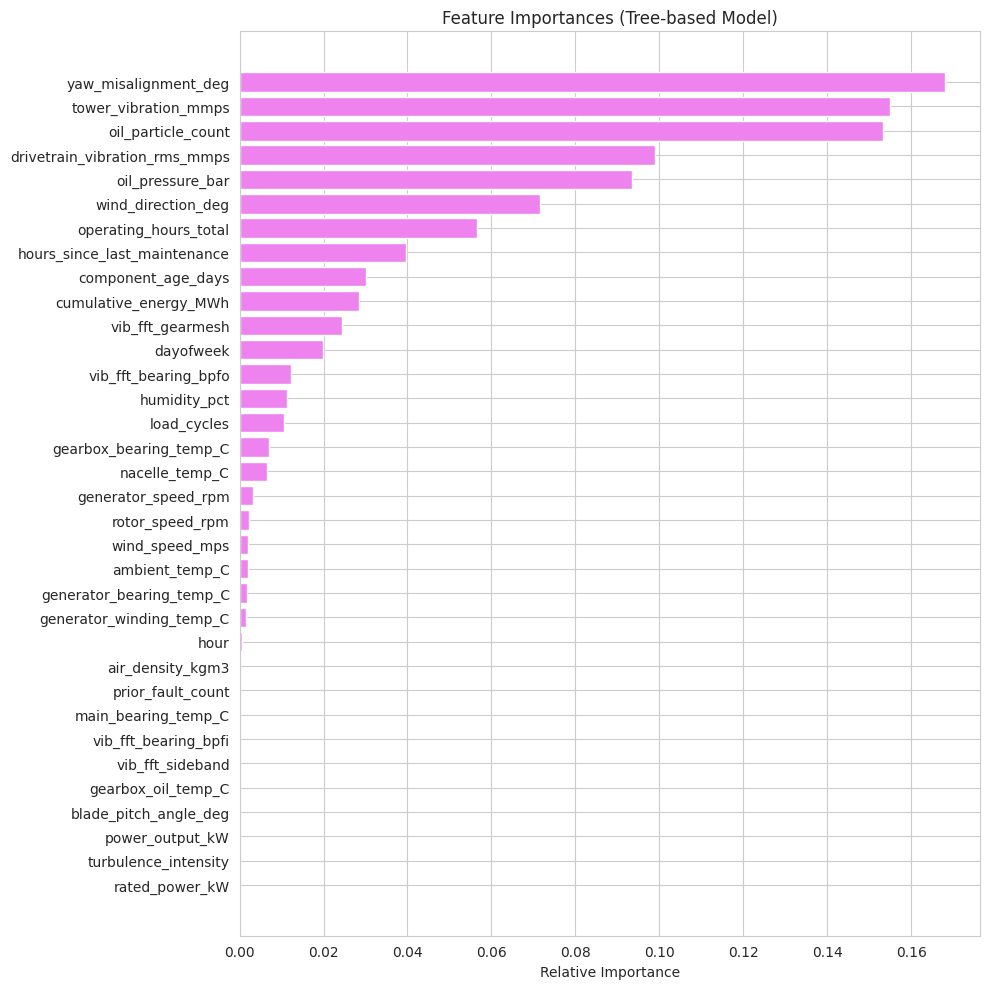

In [ ]:
plot_feature_importances(final_model, x_test, y_test)

## Final Model Test Performance

1. Evaluate the selected model using the unseen test dataset.
2. Display the performance metrics and confusion matrix to measure how well the model generalizes to new data.
3. Use the test results as the final estimate of the model's real-world performance.

Tree Perf


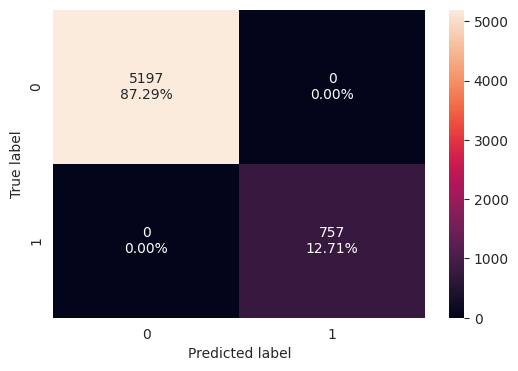

None

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5197
         1.0       1.00      1.00      1.00       757

    accuracy                           1.00      5954
   macro avg       1.00      1.00      1.00      5954
weighted avg       1.00      1.00      1.00      5954

Model Accuracy: 100.00%


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [ ]:
from scipy.stats import randint

param_grid_xgboost = {
    'n_estimators': 57,
    'max_depth': 4,
    'learning_rate': 0.01,
    'min_child_weight': 5,
    "gamma": 0.1,
    "subsample": 1.0,
    "colsample_bytree": 0.8,
    "reg_alpha": 1.0,
    "reg_lambda": 1.0,
}

xgboost_tuned_train_perf = xgboost_classify(param_grid_xgboost, x_test, y_test)

# **Business Insights and Recommendations**

##Process
- Data Collected: Supervisory   Control and Data Acquisition (SCADA) systems capture 10-minute averages of drivetrain vibration, bearing and oil temperatures, rotor and generator speed, and power output.  These samples are taken across 15 turbines
-   Model Used: Used XGBoost, a time-series anomaly detection and survival analysis model to predict the Remaining Useful Life (RUL) of the gearbox components.
- Metric Used:  F1.  This metric
 balances both high recall and high precision. This allows for limiting false negatives which  cause missed faults that can lead to castatrope. It also limits false positives which can overwhelm maintenance crews with false alarms while still catching critical faults before they happen.

## Business Insights

- Finding: Incorrect Yaw degrees contribute the most to avoidable failures.  Yaw is affected by numerous factors including bad nacelle readings, machinery wear (bearings, gears), and low power out put.  Machine wear increases when when wind speeds exceed 15 m/s, a sustained bearing temperature spike above 80°C paired with minor vibration anomalies indicates an potential turbine failure.  Yaw displacement, tower vibration, oil particle count, drivetrain vibration, oil pressure bar, hours since last maintenance, and component age in days all play significant roles in predicting failure.
- Root Cause Analysis: The data proves that standard scheduled is sufficient but misses rapid, declining degradation cycles and yaw deflection that occur during wind events or cold temperatures.

## Recommendations

-  Actionable Step 1:  Continue maintanence schedule as is, making sure to check yaw displacement, tower vibration, oil particle count, drivetrain vibration, oil pressure bar.
-  Actionable Step 2: Deploy an automated alert system that triggers a preventative maintenance inspection the moment tower vibration exceeds 1.5 rms mmps.  
-  Actionable Step 3: Deploy an automated alert system that alerts when gearbox bearing temp exceeds 75 degrees Celcius.
- Actionable Step 4: Deploy an alert when oil particle count exceeds 20.
- Actionable Step 5: Deploy an alert when yaw displacement exceeds .06 degrees.
- Actionable Step 6: Deploy an alert when tower vibration exceeds 1.437 mmps.
- Actionable Step 7: Deploy an alert when nacelle temp exceeds 27.4 degrees Celcius.
- Actionable Step 8: Monitor wind speed, wind speed is optimal for power out when it's between 11.2 and 24mph.  Higher that that the power output declines.
- Actionable Step 9: Pay attention to Turbine 001.  That turbine has the most faults.
- Actionable Step 10: Implement an automated "de-rating" protocol (temporarily capping the tower vibrations) during high-wind events if early thermal stress signs appear, extending component life until a crew arrives.
- Actionable Step 11: Shift from a rigid calendar-based maintenance schedule to a dynamic, predictive scheduling model, prioritizing technicians based on turbine health scores.


##Expected Impact

Reducing catastrophic gearbox failures saving annually in logistics and preserves power generation revenue.  The gearbox alone represents approximately 13% of the overall capital cost of an onshore turbine, and within gearboxes the failures are dominated by bearings: one widely-cited breakdown puts the split at bearings (70%), gears (26%) and other causes (4%).  Noting when these conditions are approaching danger zones can provide maintenance with guidance on where to focus their energies.